Alexander W. Criswell 2/27/26

Implementing vectorization via the new shaped distributions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import cupy as xp
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.cm
from matplotlib import patches
# import jax.numpy as jnp
# import jax; jax.config.update("jax_enable_x64", True)
from copy import deepcopy
from corner import corner, overplot_lines
import legwork as lw
import astropy.units as u
from tqdm import tqdm
from math import factorial
import scipy.stats as scst
import scipy.special as sc

In [3]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State, BranchSupplemental
from eryn.backends import SupplementalBackend
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove, DistributionGenerate, MTDistGenMove, Move
from eryn.utils.utility import groups_from_inds
from multiprocessing import Pool

In [4]:
np.random.seed(42)

In [5]:
## set environment variables
import os
os.environ['PELARGIR_GPU'] = '1'
os.environ['SCIPY_ARRAY_API'] = '1'
os.environ['PELARGIR_ERYN'] = '1'

In [6]:
if os.environ['PELARGIR_GPU']:
    print('GPU enabled.')

GPU enabled.


In [7]:
import sys
prop_path = '/home/awc/Documents/LISA/projects/lisa_population_inference/pelargir-gb/pelargir/'
sys.path.insert(1, prop_path)
from models import PopModel
from inference import GalacticBinaryPrior, PopulationHyperPrior, Res_Astro_Likelihood
from utils import get_amp_freq, lisa_noise_psd, set_style, to_numpy
from plotting import plot_spectra, plot_spectra_flexible, plot_corners, plot_model_chains, plot_model_loglikes, plot_Nres_hist
from moves import make_PriorMove, PoissonMove
import distributions as st

GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.
GPU requested and available; running Pelargir population inference on GPU.


In [8]:
set_style()

In [9]:
rng = xp.random.default_rng(170817)

In [10]:
a = st.norm(rng)

In [12]:
from cupyx.scipy import sparse

In [17]:
data = a.rvs(1)

In [18]:
data

array([-0.23218699])

In [21]:
x = sparse.csr_matrix((10,3))

In [24]:
x[3,1] = data

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/cupyx/scipy/sparse/_compressed.py:548: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive.
  warnings.warn('Changing the sparsity structure of a '


In [11]:
a.shape

()

In [21]:
a = xp.array([[1,2,6],[3,3,2]])
a.shape,xp.greater(a[:,:,None],xp.arange(xp.max(a))).shape

((2, 3), (2, 3, 6))

In [23]:
a = xp.array([1,2,6])
a.shape,xp.greater(a[:,None],xp.arange(xp.max(a)))

((3,),
 array([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True,  True,  True,  True]]))

In [27]:
b = xp.zeros((3,6))

In [29]:
c = xp.ones((3,6))
filt = xp.array([[ False, False, False, True, False, False],
        [ True,  False, False, True, False, False],
        [ True,  True,  True,  True,  True,  True]])

In [30]:
b[xp.greater(a[:,None],xp.arange(xp.max(a)))] = c[filt]

In [31]:
b

array([[1., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1.]])

In [33]:
xp.quantile(b[b!=0],0.95,axis=0)

array(1.)

In [38]:
x = xp.hstack([1e-21 * xp.arange(10000),xp.zeros(1000)])

In [41]:
xp.quantile(x,0.95),xp.quantile(1e-21 * xp.arange(10000),0.95)

(array(9.44905e-18), array(9.49905e-18))

In [43]:
xp.arange(3,10)

array([3, 4, 5, 6, 7, 8, 9])

In [12]:
a = st.norm(rng,loc=0,scale=1.1)

In [13]:
a.shape

()

In [14]:
a.loc,a.scale

(0, 1.1)

In [15]:
a = st.norm(rng,loc=xp.array([0,5]),scale=xp.array([1,0.5]))

In [16]:
a.shape

(2,)

In [17]:
a.rvs(10).shape

(10, 2)

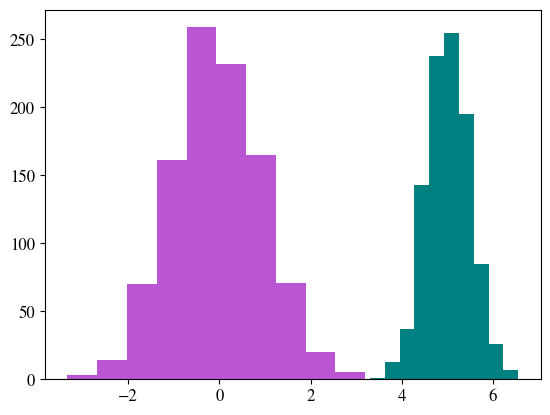

In [18]:
plt.figure()
draws = a.rvs(1000).get()
plt.hist(draws[:,0])
plt.hist(draws[:,1])
plt.show()

In [19]:
xs = xp.linspace(-5,10,100)
x = 1
y = xp.array([1,2,3])
a.logpdf(x)

array([[ -1.41893853, -32.22579135]])

In [20]:
a.logpdf(y.reshape(-1,1))

array([[ -1.41893853, -32.22579135],
       [ -2.91893853, -18.22579135],
       [ -5.41893853,  -8.22579135]])

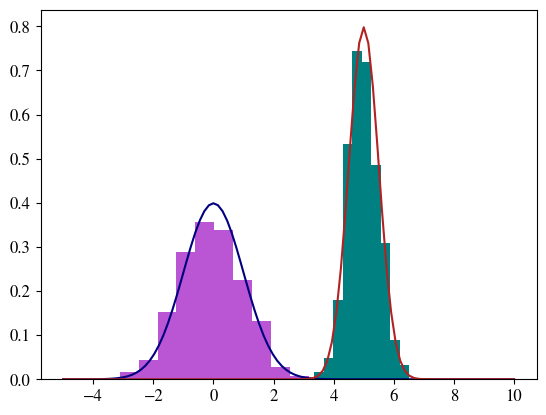

In [21]:
plt.figure()
draws = a.rvs(1000).get()
plt.hist(draws[:,0],density=True)
plt.hist(draws[:,1],density=True)
vals = np.exp(a.logpdf(xs.reshape(-1,1)).get())
plt.plot(xs.get(),vals[:,0])
plt.plot(xs.get(),vals[:,1])
plt.show()

In [22]:
z = xp.array([[1,2,3],[4,5,6]]).T
z.shape

(3, 2)

In [23]:
a.logpdf(z).shape

(6, 2)

In [24]:
b = st.norm(rng,loc=xp.array([[0,1],[2,3]]),scale=xp.array([[0.1,0.1],[0.1,0.1]]))

In [25]:
b.shape

(2, 2)

In [26]:
b.rvs(10).shape

(10, 2, 2)

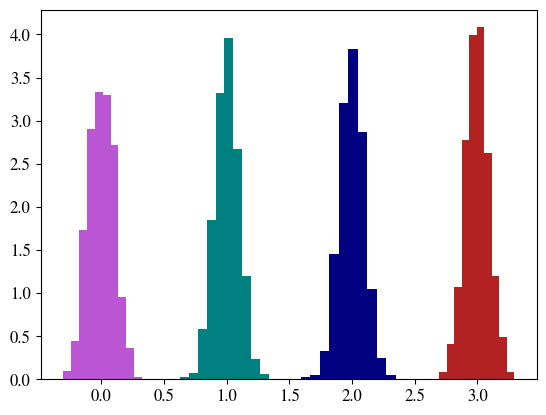

In [27]:
plt.figure()
draws = b.rvs(1000).get()
for i in range(b.shape[0]):
    for j in range(b.shape[1]):
        plt.hist(draws[:,i,j],density=True)
plt.show()

In [28]:
b.logpdf(xs).shape

(100, 2, 2)

In [29]:
b.logpdf(2).shape

(1, 2, 2)

In [30]:
xs.reshape(-1,*[1 for dim in ()]).shape

(100,)

In [31]:
st.invgamma(rng,xp.array([1,2]))

In [32]:
xp.asarray(xp.array(1))

array(1)

In [33]:
a = (1,2)
b = (3,4,5)
c = (*a,*b)
c

(1, 2, 3, 4, 5)

In [34]:
c[:len(c)-len(b)]

(1, 2)

In [35]:
np.prod((1,2))

2

In [36]:
a = np.array([[1,2,3],[0,0,1]])
a

array([[1, 2, 3],
       [0, 0, 1]])

In [37]:
a

array([[1, 2, 3],
       [0, 0, 1]])

In [38]:
a < 2

array([[ True, False, False],
       [ True,  True,  True]])

In [39]:
b = np.zeros(a.shape)

In [40]:
b[np.nonzero(a<2)][:,] = a[np.nonzero(a<2)]
b

array([[0., 0., 0.],
       [0., 0., 0.]])

In [41]:
np.nonzero(a<2)

(array([0, 1, 1, 1]), array([0, 0, 1, 2]))

In [42]:
a = xp.array([[1,2,3],[4,5,6]])

In [43]:
a = xp.random.randint(0,10,size=(5,2,2))

In [44]:
a

array([[[6, 2],
        [9, 6]],

       [[9, 4],
        [5, 6]],

       [[0, 7],
        [4, 1]],

       [[5, 6],
        [1, 7]],

       [[1, 0],
        [0, 1]]])

In [45]:
b = xp.random.shuffle(a)

In [46]:
b

In [47]:
a

array([[[5, 6],
        [1, 7]],

       [[9, 4],
        [5, 6]],

       [[6, 2],
        [9, 6]],

       [[0, 7],
        [4, 1]],

       [[1, 0],
        [0, 1]]])

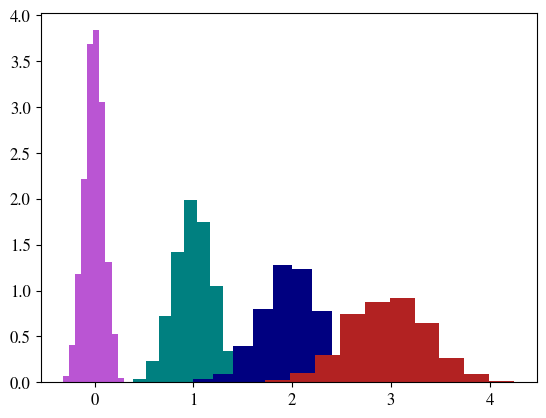

In [48]:
b = st.norm(rng,loc=xp.array([[0,1],[2,3]]),scale=xp.array([[0.1,0.2],[0.3,0.4]]))
plt.figure()
draws = b.rvs(1000)
draws_i = draws.get()
_ = xp.random.shuffle(draws)
plotdraws = draws.get()
for i in range(b.shape[0]):
    for j in range(b.shape[1]):
        plt.hist(plotdraws[:,i,j],density=True)
plt.show()

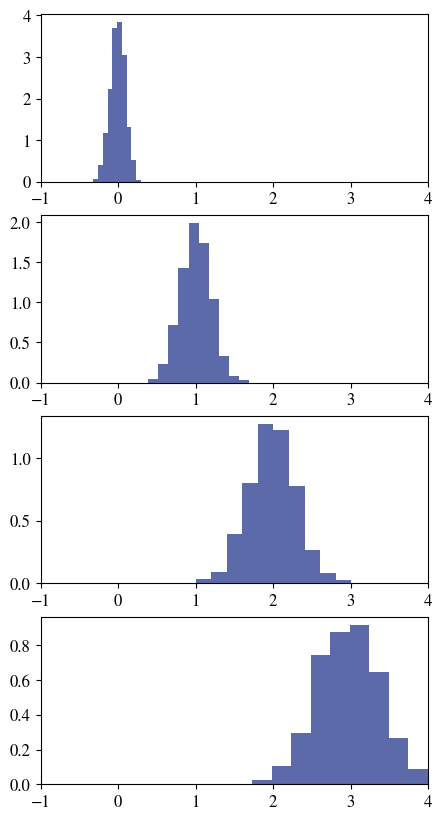

In [49]:
fig, axes = plt.subplots(4,1,figsize=(5,10))
axi = 0
for i in range(b.shape[0]):
    for j in range(b.shape[1]):
        axes[axi].set_xlim(-1,4)
        axes[axi].hist(plotdraws[:,i,j],density=True)
        axes[axi].hist(draws_i[:,i,j],density=True,alpha=0.5)
        axi += 1
        
plt.show()

In [50]:
draws_i

array([[[ 0.01195779,  1.01495628],
        [ 2.2101051 ,  3.19964706]],

       [[ 0.05006596,  1.37277463],
        [ 2.27362819,  3.40623888]],

       [[ 0.084054  ,  1.05202371],
        [ 2.0990757 ,  2.83193144]],

       ...,

       [[-0.09657377,  0.91168263],
        [ 2.1285623 ,  2.73449588]],

       [[ 0.01168585,  1.04393658],
        [ 1.74992974,  3.13985166]],

       [[-0.03926656,  1.00859261],
        [ 2.28002425,  2.64377178]]])

In [51]:
plotdraws

array([[[ 0.0201082 ,  0.84367104],
        [ 2.29808115,  2.73688571]],

       [[-0.11976262,  1.27887146],
        [ 2.06630366,  2.89787104]],

       [[-0.12005408,  0.59056998],
        [ 2.15632404,  3.30063331]],

       ...,

       [[ 0.18427643,  0.93513283],
        [ 2.02041587,  2.31793356]],

       [[ 0.04690252,  0.95826409],
        [ 1.7843459 ,  2.66255017]],

       [[ 0.04287502,  0.74725706],
        [ 1.90633013,  2.69208585]]])

In [60]:
a = np.array([1,2])

In [62]:
np.expand_dims(a,0).shape

(1, 2)

In [63]:
np.repeat(np.expand_dims(a,0),5,axis=0).shape

(5, 2)

In [56]:
a.reshape(-1,1).shape

(1, 1)

In [ ]:
np.repeat(a.reshape(-1,1),axis=0)

In [64]:
[i for i in range(1)]

[0]

In [70]:
np.expand_dims(a,()).shape

(2,)

In [69]:
tuple([10,2])

(10, 2)

In [104]:
a.shuffle()

AttributeError: 'ndarray' object has no attribute 'shuffle'

In [100]:
def shuf(a):
    xp.random.shuffle(a)
    return a

In [101]:
shuf(a)

array([[4, 5, 6],
       [1, 2, 3]])

In [75]:
xp.apply_along_axis(xp.random.shuffle,0,a)

ValueError: Unsupported dtype object

In [66]:
np.put_along_axis(b,np.array(np.nonzero(a>0)),10,axis=0)

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (2,4) (1,3) 

In [10]:
import numpy as np
a = np.empty((10,4,2))
for i in range(2):
    for j in range(4):
        a[:,j,i] = (i+1)*np.arange(10)
a.reshape(-1,2)

array([[ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 1.,  2.],
       [ 1.,  2.],
       [ 1.,  2.],
       [ 1.,  2.],
       [ 2.,  4.],
       [ 2.,  4.],
       [ 2.,  4.],
       [ 2.,  4.],
       [ 3.,  6.],
       [ 3.,  6.],
       [ 3.,  6.],
       [ 3.,  6.],
       [ 4.,  8.],
       [ 4.,  8.],
       [ 4.,  8.],
       [ 4.,  8.],
       [ 5., 10.],
       [ 5., 10.],
       [ 5., 10.],
       [ 5., 10.],
       [ 6., 12.],
       [ 6., 12.],
       [ 6., 12.],
       [ 6., 12.],
       [ 7., 14.],
       [ 7., 14.],
       [ 7., 14.],
       [ 7., 14.],
       [ 8., 16.],
       [ 8., 16.],
       [ 8., 16.],
       [ 8., 16.],
       [ 9., 18.],
       [ 9., 18.],
       [ 9., 18.],
       [ 9., 18.]])

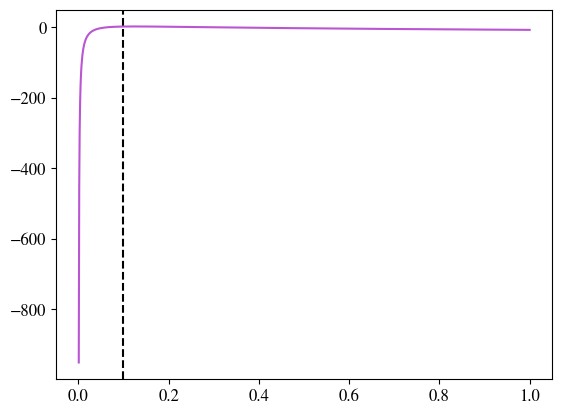

In [34]:
plt.figure()
xs = np.linspace(0,1,1000)
plt.plot(xs,st.invgamma(test_rng,7,cast=True).logpdf(xs))
plt.axvline(0.1,c='k',ls='--')
plt.show()

In [29]:
test_prior = GalacticBinaryPrior(test_rng)

In [30]:
pop_theta = {'m_mu':xp.array([0.6]),'m_sigma':xp.array([0.1]),
             'rh_disk':xp.array([3.31]),'r_bulge':xp.array([0.75]),'q_bd':xp.array([0.33]),
             'a_alpha':xp.array([1/2])}
test_prior.condition(pop_theta)

In [31]:
samps = test_prior.sample_conditional((int(1e6),))

In [32]:
samps.shape

(4, 1000000)

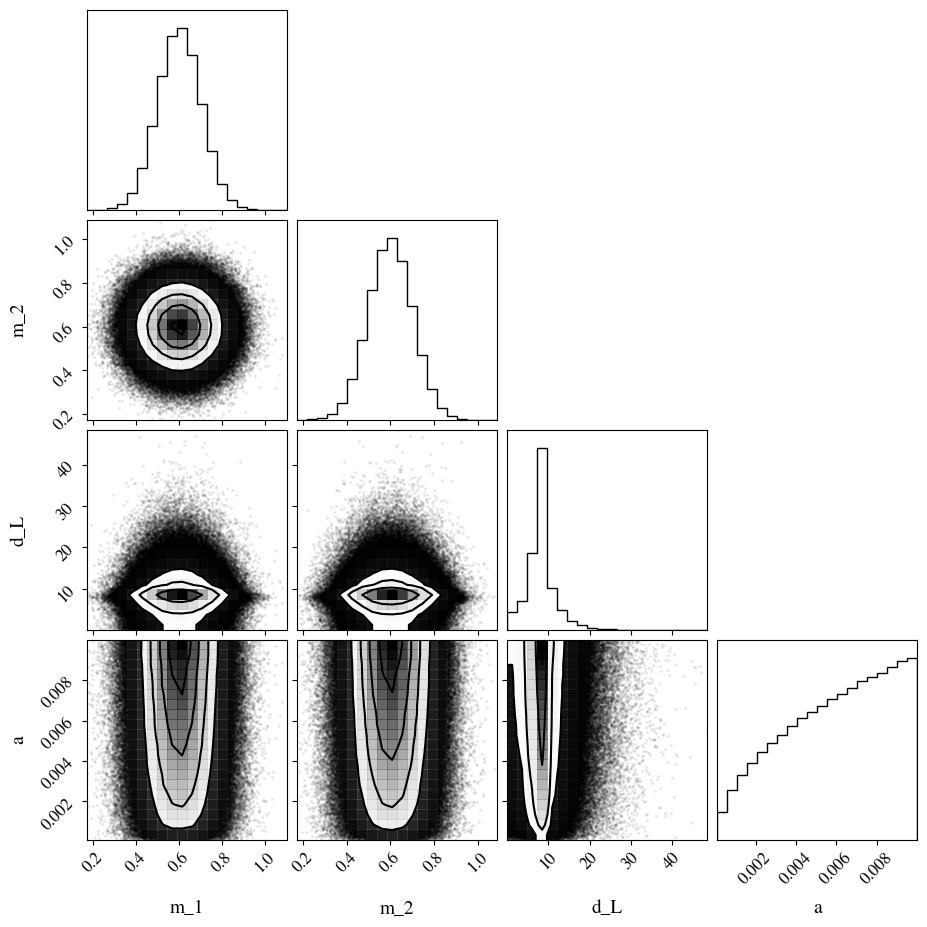

In [33]:
plt.close()
fig = corner(samps.get().T,labels=list(test_prior.conditional_dict.keys()))
plt.show()

Okay. From here let's prototype the simplest possible thing. Let's take all the true vals, perturb each of them by ~10%, and apply the appropriate bounds. Define a function to do this:

In [34]:
samps

array([[7.39355661e-01, 5.70266516e-01, 6.43882779e-01, ...,
        6.91334904e-01, 5.55735464e-01, 4.14290074e-01],
       [5.27720985e-01, 4.99405050e-01, 7.23480643e-01, ...,
        4.97681293e-01, 6.66088810e-01, 4.36558540e-01],
       [7.51959017e+00, 1.14345989e+01, 7.11713614e+00, ...,
        8.02252059e+00, 7.85324536e+00, 8.74221428e+00],
       [8.34249086e-03, 1.89503890e-03, 5.51003168e-03, ...,
        4.89870107e-03, 7.31557659e-03, 9.97584591e-03]])

In [35]:
xp.sum(samps[3,:] > 1e-2)

array(0)

In [36]:
xp.max(samps[3,:])

array(0.00999998)

In [37]:
def scatter_thetas(rng,theta_true,err=xp.array([0.05,0.05,0.1,0.001])):
    scattered_theta = xp.empty_like(theta_true)
    ## orbital separation to log space
    theta_temp = theta_true.copy()
    theta_temp[:,-1] = xp.log10(theta_true[:,-1])
    for ii in range(theta_true.shape[-1]):
        scattered_theta[:,ii] = theta_temp[:,ii] + err[ii]*st.norm(rng).rvs(theta_true.shape[0])
    ## orbital separation back to linear space
    scattered_theta[:,-1] = 10**scattered_theta[:,-1]

    return scattered_theta

    

In [38]:
test_sct = scatter_thetas(test_rng,samps.T,err=xp.array([0.05,0.05,0.5,1e-2]))

In [39]:
## now just simulate prior bounding by wrapping anything outside the bounds to be within them
def apply_theta_lims(scattered_theta,theta_lims='default'):
    if theta_lims == 'default':
        ## set minimum allowed distance in kpc
        d_min = 1e-3 ## no GBs closer than the closest known star
        d_max = 100 ## reasonably far past the edge of the Galaxy
        a_min = 1e-4 ## no binaries with a semimajor axis comparable to their radius
        a_max = 1e-2 ## no binaries outside of LISA's frequency range
        m_min = 0.17 ## lowest-mass observed white dwarf
        m_max = 1.44 ## no WDs with mass above the Chandrasekar limit
        theta_lims = xp.array([[m_min,m_max],[m_min,m_max],[d_min,d_max],[a_min,a_max]])

    bounded_theta = scattered_theta
    for ii in range(scattered_theta.shape[-1]):
        lower_filt_ii = bounded_theta[:,ii] <= theta_lims[ii,0]
        upper_filt_ii = bounded_theta[:,ii] >= theta_lims[ii,1]
        bounded_theta[lower_filt_ii,ii] = 1.0000001*theta_lims[ii,0]
        bounded_theta[upper_filt_ii,ii] = 0.9999999*theta_lims[ii,1]
    
    return bounded_theta
            

In [40]:
test_bt = apply_theta_lims(test_sct)

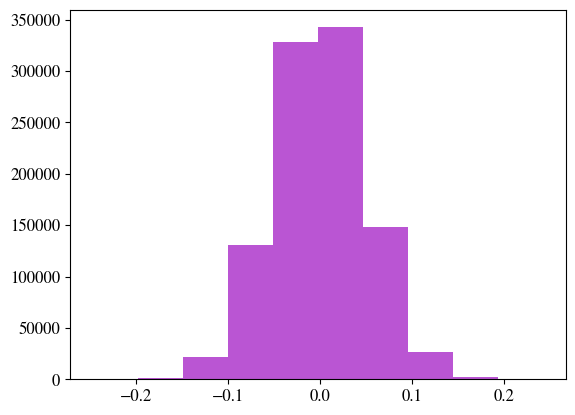

In [41]:
plt.figure()
plt.hist((samps.T[:,0]-test_sct[:,0]).get())
plt.show()

In [42]:
test_bt

array([[6.68605274e-01, 5.14602971e-01, 7.32690242e+00, 8.28113406e-03],
       [5.92074884e-01, 5.46467368e-01, 1.16483043e+01, 1.92352435e-03],
       [6.82143429e-01, 6.74226172e-01, 7.38687026e+00, 5.73196838e-03],
       ...,
       [6.68437024e-01, 4.14012796e-01, 8.64589952e+00, 4.89687783e-03],
       [6.14505249e-01, 5.53243663e-01, 7.99413286e+00, 7.21138829e-03],
       [4.30730275e-01, 4.08118854e-01, 8.43764746e+00, 9.99999900e-03]])

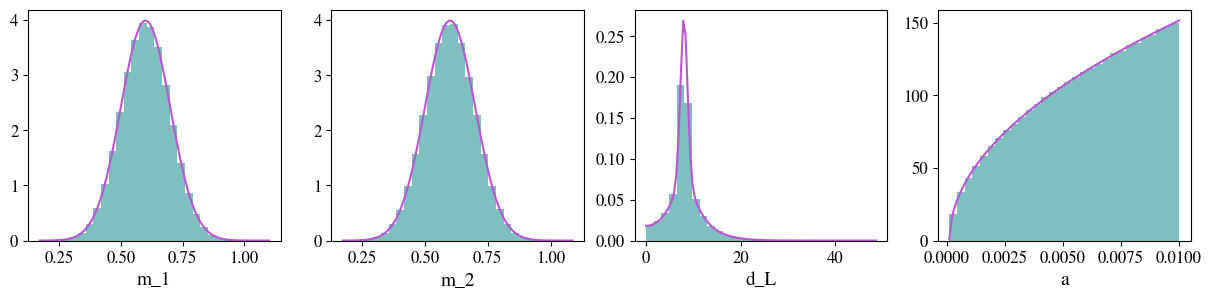

In [67]:
## prototyping some plot code
plt.close()
fig, axes = plt.subplots(nrows=1,ncols=4,figsize=(15,3))
names = list(test_prior.prior_dict.keys())
for i, ax in enumerate(axes):
    samps_i = samps[i,:].get()
    ax.hist(samps_i,density=True,bins=30,alpha=0.5,color='teal')
    low = samps_i.min()
    high = samps_i.max()
    xvals = np.linspace(low,high,100)
    ax.plot(xvals,np.exp(test_prior.conditional_dict[names[i]].logpdf(xvals)).get())
    ax.set_xlabel(names[i])
plt.show()

In [59]:
test_prior.prior_dict.keys()

dict_keys(['m_1', 'm_2', 'd_L', 'a'])

In [68]:
xp.sum(samps[3,:] > 1e-2)

CUDARuntimeError: cudaErrorLaunchFailure: unspecified launch failure

In [137]:
test_prior.conditional_logpdf(test_bt)

array([[ 1.38062794,  1.38089288, -1.76460454, -0.60296471],
       [ 0.57971123,  1.32825752, -3.46906244, -0.51785527],
       [ 1.34214319,  0.34310271, -2.68179161,  0.08659838],
       ...,
       [ 1.37902945,  1.36099462, -1.6774583 ,  0.39165134],
       [ 1.33369064,  1.30977835, -1.70155362, -0.21272128],
       [ 1.326939  ,  1.37265101, -3.04601986,  0.23376664]])

In [138]:
test_hprior = PopulationHyperPrior(test_rng)

In [156]:
test_prior_2 = GalacticBinaryPrior(test_rng)

In [157]:
Nsamp = 1000
likes = xp.empty(Nsamp)
draws = xp.empty((Nsamp,6))
for ii in range(Nsamp):
    draw = test_hprior.sample()
    test_prior_2.condition(draw)
    draws[ii,:] = xp.array([draw['m_mu'],draw['m_sigma'],
                            draw['rh_disk'],draw['r_bulge'],draw['q_bd'],
                            draw['a_alpha']]).flatten()
    likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_bt))

In [158]:
draws[-1,:]

array([0.47928716, 0.23709995, 2.23996897, 0.15362184, 0.58604749,
       0.33801891])

In [159]:
test_bt[xp.isinf(test_prior_2.conditional_logpdf(test_bt))]

array([], dtype=float64)

In [160]:
test_prior_2.conditional_logpdf(xp.array([6.03997750e-01, 4.83951848e-01, 8.59380571e+00, 2.47292474e-03]))

array([ 0.4830025 ,  0.62113812, -2.63377251, -0.20154   ])

In [161]:
xp.sum(xp.isinf(likes))

array(0)

(array([  4.,   0.,   2.,   2.,   3.,  21.,  22.,  54., 161., 731.]),
 array([-30558511.90591366, -27604557.68866298, -24650603.4714123 ,
        -21696649.25416162, -18742695.03691094, -15788740.81966026,
        -12834786.60240958,  -9880832.3851589 ,  -6926878.16790822,
         -3972923.95065754,  -1018969.73340686]),
 <BarContainer object of 10 artists>)

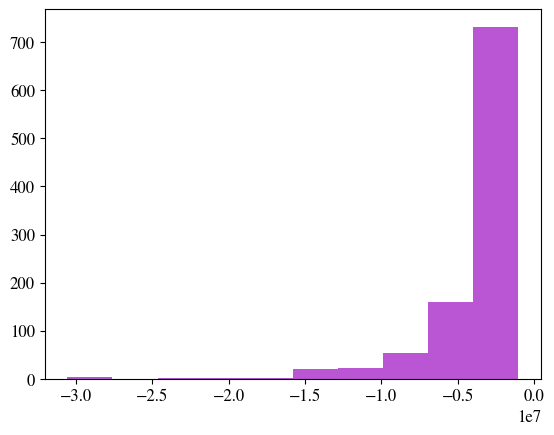

In [162]:
plt.hist(likes.get())

In [163]:
draws.shape

(1000, 6)

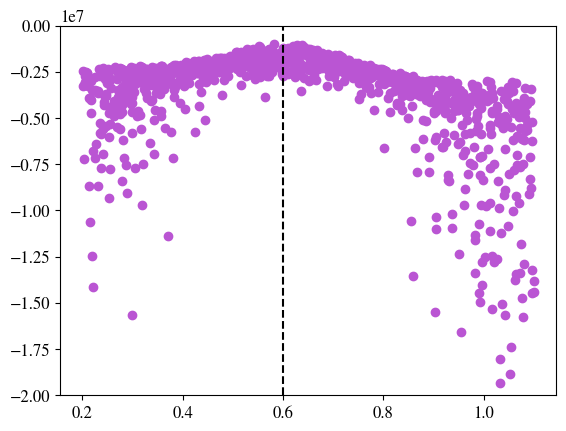

In [164]:
plt.figure()
plt.scatter(draws[:,0].get(),likes.get())
plt.axvline(0.6,ls='--',c='k')
plt.ylim(-2e7,0)
plt.show()

In [165]:
xp.argmax(likes)

array(316)

In [166]:
draws[xp.argmax(likes),:]

array([0.58247318, 0.12731258, 4.79682017, 1.86069484, 0.22275881,
       0.48195911])

In [167]:
pop_theta

{'m_mu': array([0.6]),
 'm_sigma': array([0.1]),
 'rh_disk': array([3.31]),
 'r_bulge': array([0.75]),
 'q_bd': array([0.33]),
 'a_alpha': array([0.5])}

In [168]:
theta_true = xp.array([pop_theta[key] for key in pop_theta.keys()]).flatten()

In [169]:
deltas = xp.linspace(-0.9,0.9,21)

In [170]:
shifts = theta_true.reshape(-1,1) + theta_true.reshape(-1,1)*deltas

In [171]:
shift_likes = xp.empty(21)
for ii in range(21):
    test_prior_2.condition(shifts[:,ii])
    shift_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_sct))

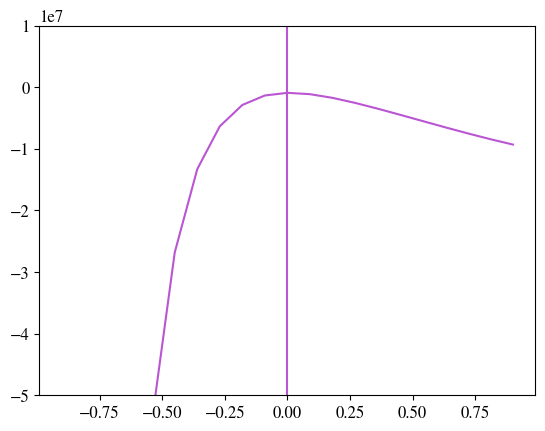

In [172]:
plt.figure()
plt.plot(deltas.get(),shift_likes.get())
plt.axvline(deltas[xp.argmax(shift_likes)].get())
plt.ylim(-0.5e8,1e7)
plt.show()

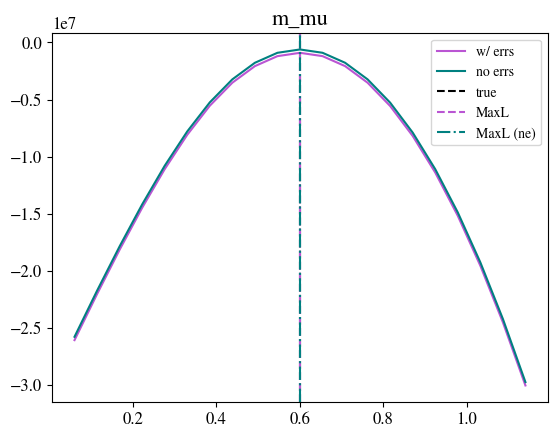

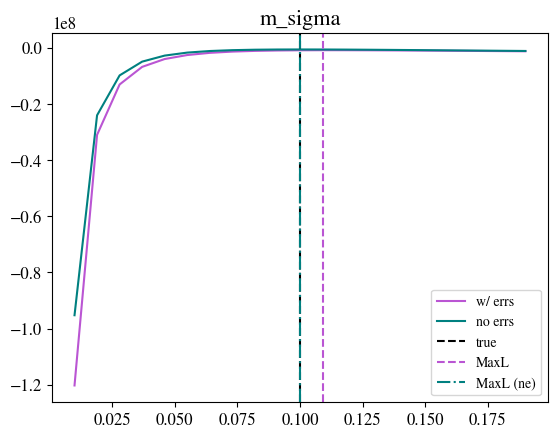

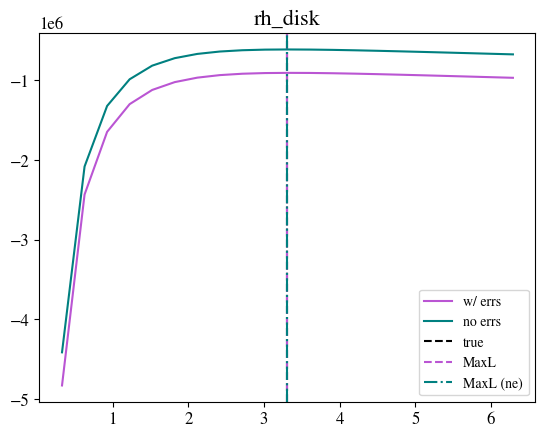

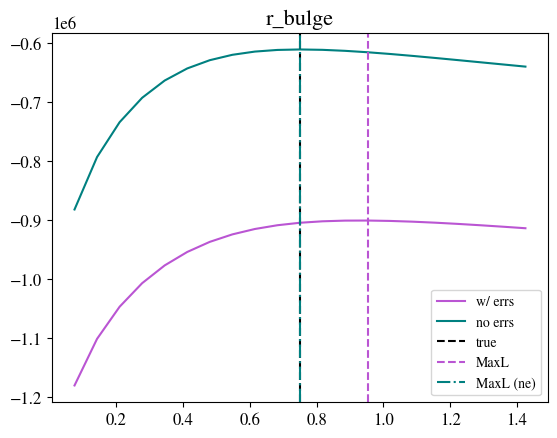

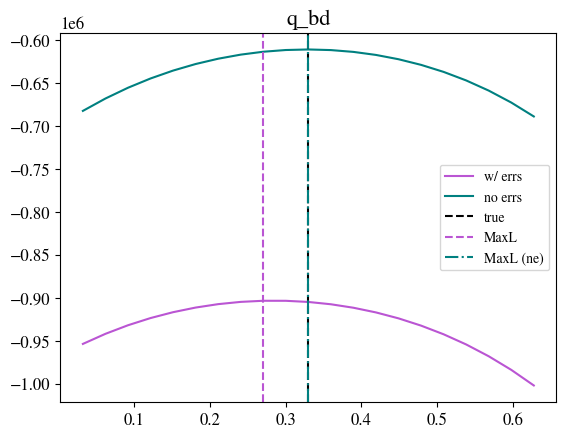

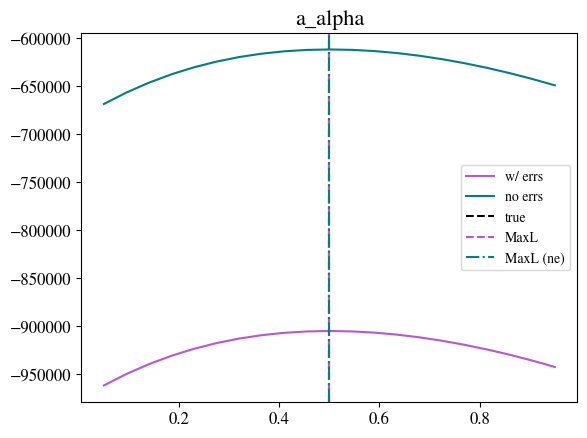

In [174]:
names = list(pop_theta.keys())
base_delta = xp.zeros((6,21))
for jj in range(6):
    name = names[jj]
    temp_delta = base_delta.copy()
    temp_delta[jj,:] = deltas
    shifts = theta_true.reshape(-1,1) + theta_true.reshape(-1,1)*temp_delta
    shift_likes = xp.empty(21)
    no_err_likes = xp.empty_like(shift_likes)
    for ii in range(21):
        test_prior_2.condition(shifts[:,ii])
        shift_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_bt))
        no_err_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(samps.T))
    plt.figure()
    plt.plot(shifts[jj,:].get(),shift_likes.get(),label='w/ errs')
    plt.plot(shifts[jj,:].get(),no_err_likes.get(),label='no errs')
    plt.axvline(pop_theta[name].get(),ls='--',c='k',label='true')
    plt.axvline(shifts[jj,:][xp.argmax(shift_likes)].get(),ls='--',c='mediumorchid',label='MaxL')
    plt.axvline(shifts[jj,:][xp.argmax(no_err_likes)].get(),ls='-.',c='teal',label='MaxL (ne)')
    plt.legend()
    plt.title(list(pop_theta.keys())[jj])
    plt.show()

In [177]:
test_hprior = PopulationHyperPrior(test_rng)

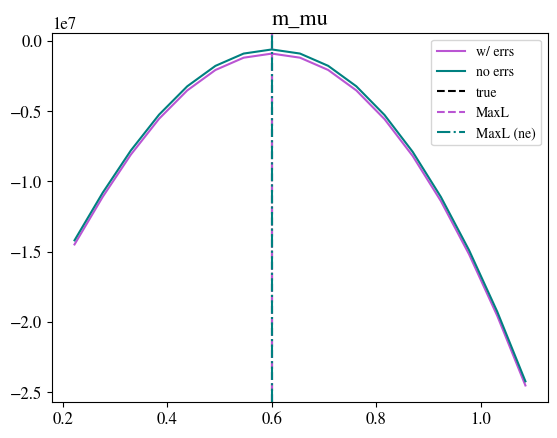

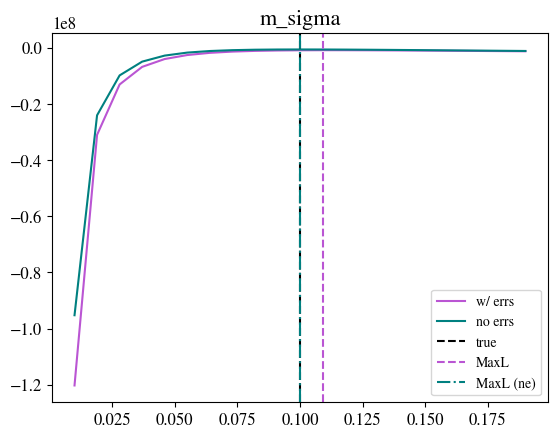

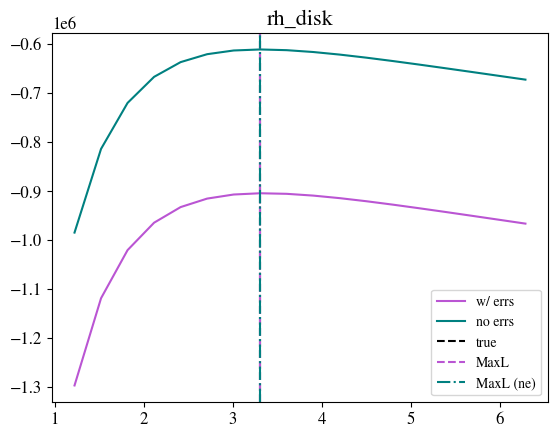

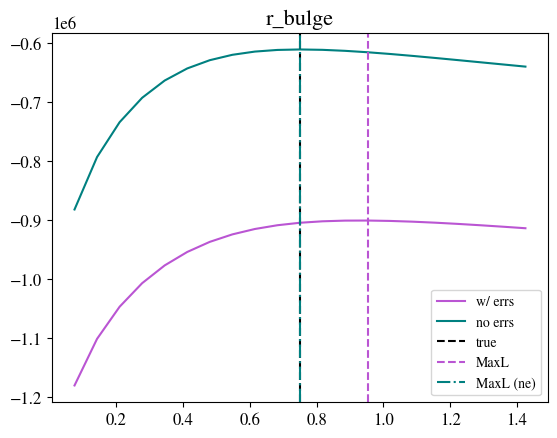

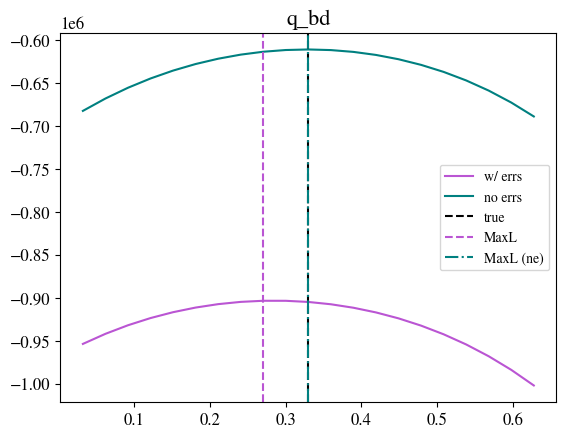

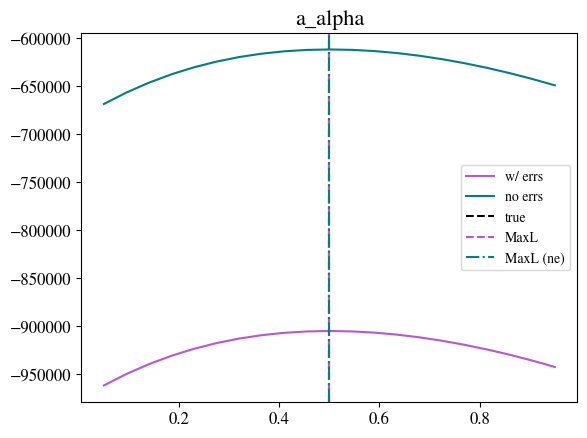

In [178]:
## posteriors

names = list(pop_theta.keys())
base_delta = xp.zeros((6,21))
maxL_vals = xp.empty(6)
for jj in range(6):
    name = names[jj]
    temp_delta = base_delta.copy()
    temp_delta[jj,:] = deltas
    shifts = theta_true.reshape(-1,1) + theta_true.reshape(-1,1)*temp_delta
    shift_likes = xp.empty(21)
    no_err_likes = xp.empty_like(shift_likes)
    for ii in range(21):
        test_prior_2.condition(shifts[:,ii])
        shift_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_bt)) + test_hprior.logpdf(shifts[:,ii])[jj]
        no_err_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(samps.T)) + test_hprior.logpdf(shifts[:,ii])[jj]
    maxL_vals[jj] = shifts[jj,xp.argmax(shift_likes)]
    plt.figure()
    plt.plot(shifts[jj,:].get(),shift_likes.get(),label='w/ errs')
    plt.plot(shifts[jj,:].get(),no_err_likes.get(),label='no errs')
    plt.axvline(pop_theta[name].get(),ls='--',c='k',label='true')
    plt.axvline(shifts[jj,:][xp.argmax(shift_likes)].get(),ls='--',c='mediumorchid',label='MaxL')
    plt.axvline(shifts[jj,:][xp.argmax(no_err_likes)].get(),ls='-.',c='teal',label='MaxL (ne)')
    plt.legend()
    plt.title(list(pop_theta.keys())[jj])
    plt.show()

In [179]:
test_hprior.logpdf(shifts[:,ii])[jj]

array(-0.69314718)

In [180]:
test_prior.prior_dict['m_1']

distributions.truncnorm

Okay good, let's do the monte carlo test on each

In [196]:
assert 'string'

In [236]:
def mc_test(name,pt,lower,upper,Nmc=100,Ndraw=1e6,density=100,scatter=False):
    '''
    name - parameter name to test, all else held fixed
    pt - pop_theta
    lower, upper - bounds on loglike grid
    Nmc - number of times to do the MC trial
    Ndraw - number of binaries to draw each trial
    density - number of points in the loglike grid
    '''
    scales = np.linspace(lower,upper,density)
    ll = np.empty_like(scales)
    for par in pt.keys():
        if par==name:
            test_par = par
            print(test_par)
    assert test_par
    prior = GalacticBinaryPrior(test_rng)
    prior.condition(pt)
    test_dist = GalacticBinaryPrior(test_rng)
    test_pt = pt.copy()
    plt.figure()
    for jj in tqdm(range(Nmc)):
        samps = prior.sample_conditional((int(Ndraw),))
        samps_sct = scatter_thetas(test_rng,samps.T,err=xp.array([0.05,0.05,0.5,1e-2]))
        samps_bt = apply_theta_lims(samps_sct)
        for ii in range(len(scales)):
            test_pt[test_par] = scales[ii]
            test_dist.condition(test_pt)
            if scatter:
                test_ll = test_dist.conditional_logpdf(samps_bt)
            else:
                test_ll = test_dist.conditional_logpdf(samps.T)
            ll[ii] = np.sum(test_ll[np.isfinite(test_ll)])
    
        plt.plot(scales,ll)
        plt.axvline(scales[np.argmax(ll)],alpha=0.5)
    plt.axvline(pt[name].get(),c='k',ls='--')
    plt.show()
    return ll

In [227]:
pop_theta

{'m_mu': array([0.6]),
 'm_sigma': array([0.1]),
 'rh_disk': array([3.31]),
 'r_bulge': array([0.75]),
 'q_bd': array([0.33]),
 'a_alpha': array([0.5])}

m_sigma


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.25it/s]


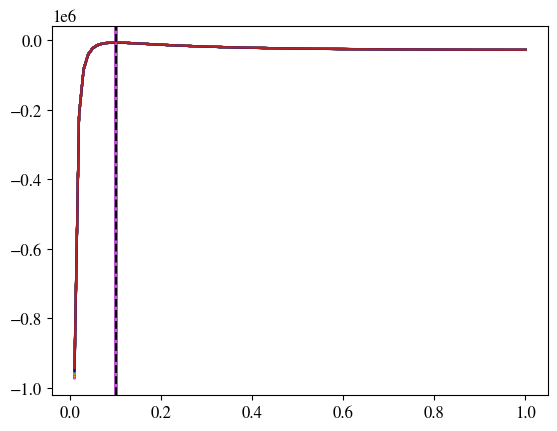

In [229]:
out = mc_test('m_sigma',pop_theta,lower=0.01,upper=1,Nmc=100,Ndraw=1e4,density=100)

m_mu


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.33it/s]


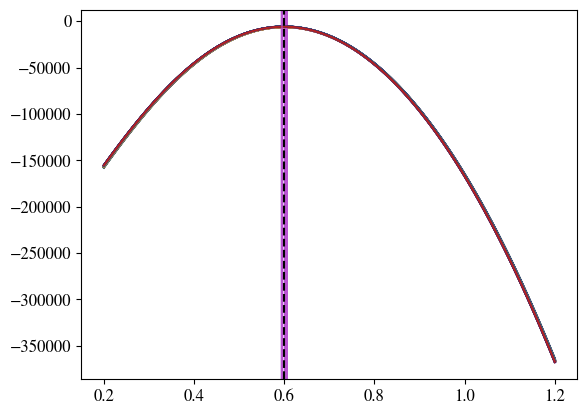

In [230]:
out = mc_test('m_mu',pop_theta,lower=0.2,upper=1.2,Nmc=100,Ndraw=1e4,density=100)

a_alpha


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.41it/s]


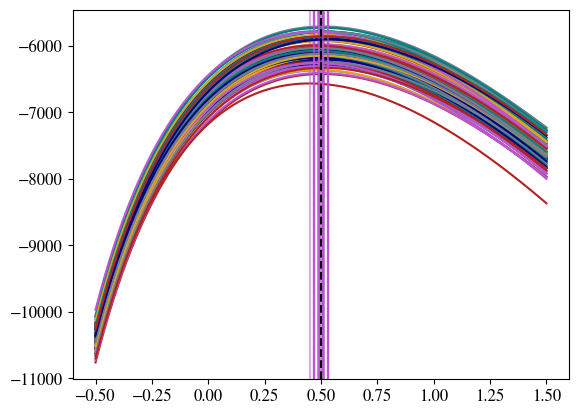

In [231]:
out = mc_test('a_alpha',pop_theta,lower=-0.5,upper=1.5,Nmc=100,Ndraw=1e4,density=100)

rh_disk


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.27it/s]


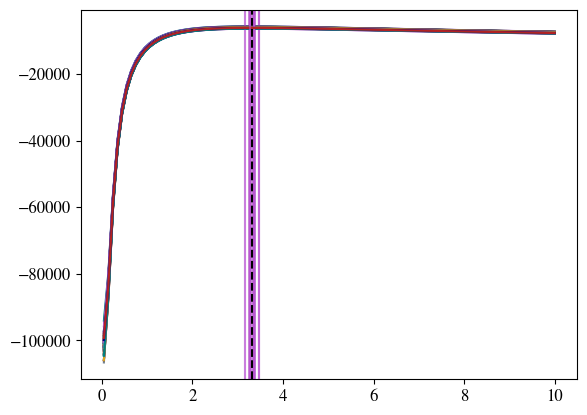

In [233]:
out = mc_test('rh_disk',pop_theta,lower=0.05,upper=10,Nmc=100,Ndraw=1e4,density=100)

r_bulge


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.30it/s]


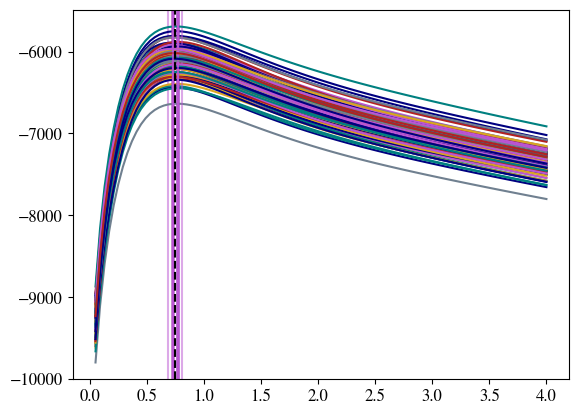

In [234]:
out = mc_test('r_bulge',pop_theta,lower=0.05,upper=4,Nmc=100,Ndraw=1e4,density=100)

q_bd


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.36it/s]


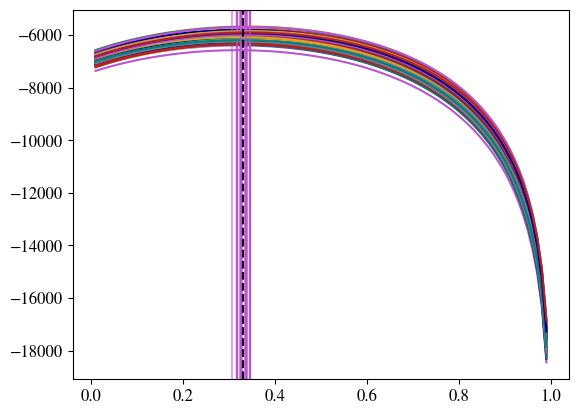

In [235]:
out = mc_test('q_bd',pop_theta,lower=0.01,upper=0.99,Nmc=100,Ndraw=1e4,density=100)

## it's wooorrrrrkiiiiiinnnnnnnnggg!!!

Now with scatter:

m_sigma


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.22it/s]


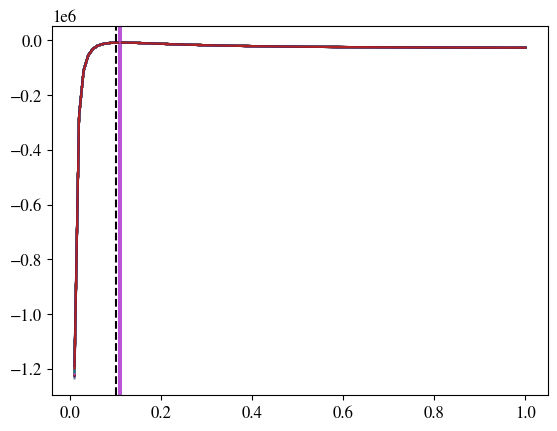

In [237]:
out = mc_test('m_sigma',pop_theta,lower=0.01,upper=1,Nmc=100,Ndraw=1e4,density=100,scatter=True)

m_mu


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.40it/s]


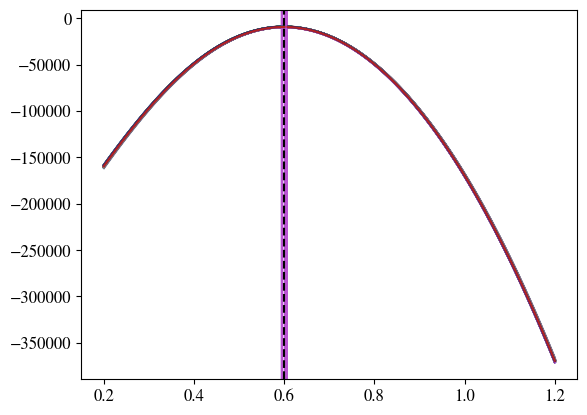

In [238]:
out = mc_test('m_mu',pop_theta,lower=0.2,upper=1.2,Nmc=100,Ndraw=1e4,density=100,scatter=True)

a_alpha


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.38it/s]


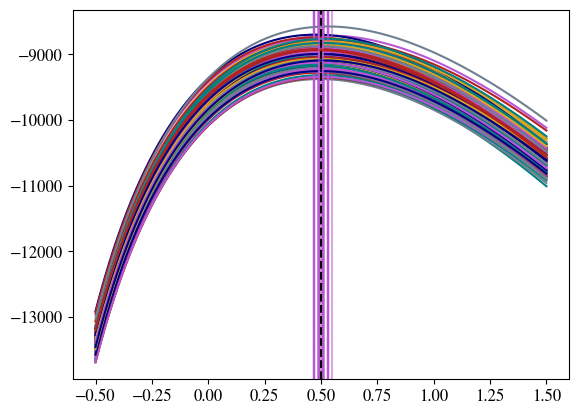

In [239]:
out = mc_test('a_alpha',pop_theta,lower=-0.5,upper=1.5,Nmc=100,Ndraw=1e4,density=100,scatter=True)

rh_disk


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.30it/s]


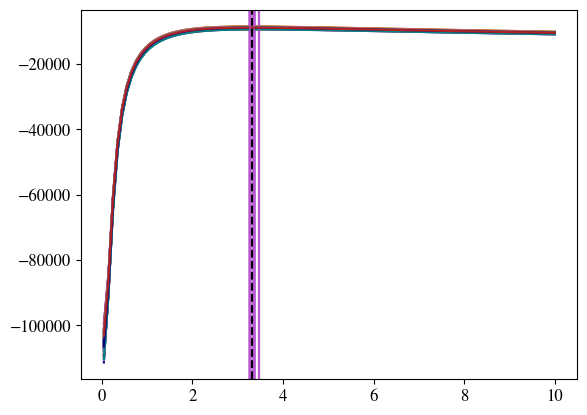

In [240]:
out = mc_test('rh_disk',pop_theta,lower=0.05,upper=10,Nmc=100,Ndraw=1e4,density=100,scatter=True)

r_bulge


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.30it/s]


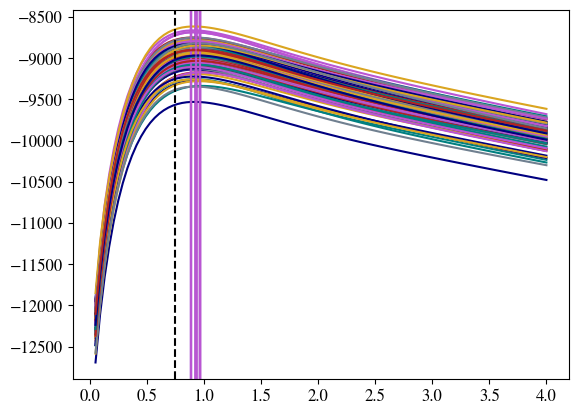

In [241]:
out = mc_test('r_bulge',pop_theta,lower=0.05,upper=4,Nmc=100,Ndraw=1e4,density=100,scatter=True)

q_bd


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.40it/s]


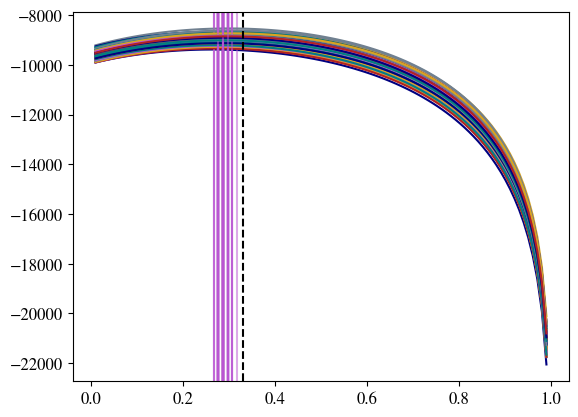

In [242]:
out = mc_test('q_bd',pop_theta,lower=0.01,upper=0.99,Nmc=100,Ndraw=1e4,density=100,scatter=True)

Leaving off here. Next steps:

1. Prototype the full liklihood with scatter and resolved GBs handled as above.
2. Do some (limited) tests
3. Implement into run_pelargir
4. Test full run on cluster

In [77]:
maxL_vals

array([0.6   , 0.109 , 3.0121, 0.033 , 0.5   ])

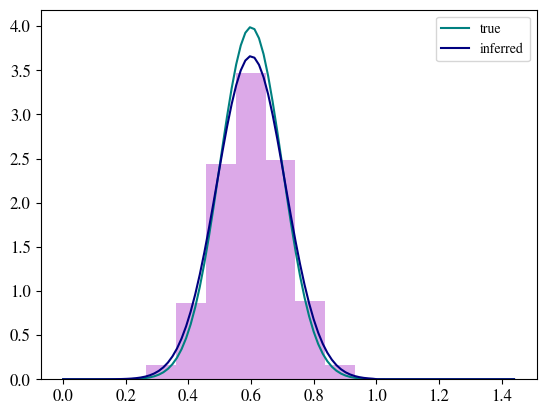

In [78]:
mx = np.linspace(0,1.44,100)
plt.figure()
plt.hist(test_bt[:,0].get(),density=True,alpha=0.5)
plt.plot(mx,np.exp(st.truncnorm(test_rng,loc=0.6,scale=0.1,cast=True).logpdf(mx)),label='true')
plt.plot(mx,np.exp(st.truncnorm(test_rng,loc=0.6,scale=maxL_vals[1],cast=True).logpdf(mx)),label='inferred')
plt.legend()
plt.show()

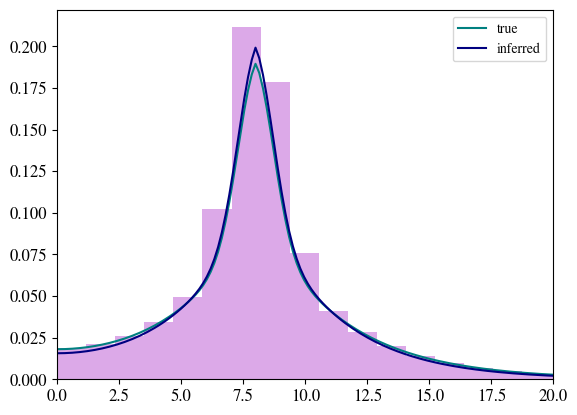

In [94]:
dx = np.linspace(0,30,200)
plt.figure()
plt.hist(test_bt[:,2].get(),density=True,alpha=0.5,bins=40)
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=3.31,
                                                   bulge_scale=0.75,
                                                   beta=0.33,cast=True).logpdf(dx)),label='true')
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=maxL_vals[2],
                                                   bulge_scale=0.75,
                                                   beta=0.33,cast=True).logpdf(dx)),label='inferred')
plt.legend()
plt.xlim(0,20)
plt.show()

In [80]:
samps_ii = test_prior.sample_conditional((int(1e6),))


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [10:11<00:00,  1.22s/it]


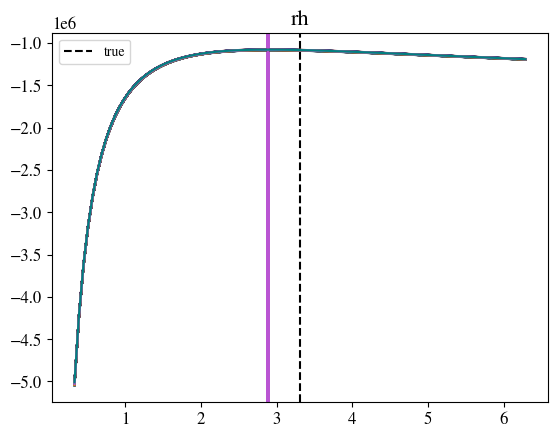

In [82]:
names = list(pop_theta.keys())
ndelt = 101
deltas = xp.linspace(-0.9,0.9,ndelt)
base_delta = xp.zeros((5,ndelt))
jj=2
name = names[jj]
temp_delta = base_delta.copy()
temp_delta[jj,:] = deltas
shifts = theta_true.reshape(-1,1) + theta_true.reshape(-1,1)*temp_delta
shift_likes = xp.empty(ndelt)
no_err_likes = xp.empty_like(shift_likes)
plt.figure()
for i in tqdm(range(500)):
    samps_i = test_prior.sample_conditional((int(1e6),))
    test_sct_i = scatter_thetas(test_rng,samps_i.T,err=xp.array([0.05,0.05,0.5,1e-2]))
    test_bt_i = apply_theta_lims(test_sct_i)
    for ii in range(ndelt):
        test_prior_2.condition(shifts[:,ii])
        shift_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_bt_i))
        no_err_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(samps_i.T))
    
    plt.plot(shifts[jj,:].get(),shift_likes.get())
    # plt.plot(shifts[jj,:].get(),no_err_likes.get(),label='no errs')
    
    plt.axvline(shifts[jj,:][xp.argmax(shift_likes)].get(),c='mediumorchid',alpha=0.1)
    # plt.axvline(shifts[jj,:][xp.argmax(no_err_likes)].get(),ls='-.',c='teal',label='MaxL (ne)')
plt.axvline(pop_theta[name].get(),ls='--',c='k',label='true')
plt.legend()
plt.title(list(pop_theta.keys())[jj])
plt.show()

In [83]:
test_prior_2p9 = GalacticBinaryPrior(test_rng)

In [84]:
pop_theta_2p9 = {'m_mu':xp.array([0.6]),'m_sigma':xp.array([0.1]),
             # 'd_mu':xp.array([30]),'d_sigma':xp.array([10]),
             'rh':xp.array([2.9]),'bdq':xp.array([0.33]),
             'a_alpha':xp.array([1/2])}
test_prior_2p9.condition(pop_theta_2p9)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:01<00:00,  1.22s/it]


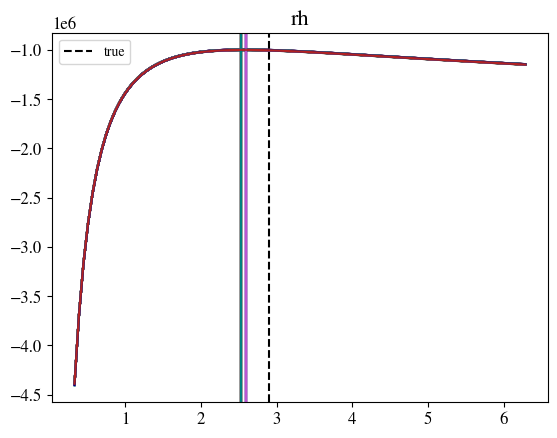

In [86]:
names = list(pop_theta_2p9.keys())
ndelt = 101
deltas = xp.linspace(-0.9,0.9,ndelt)
base_delta = xp.zeros((5,ndelt))
jj=2
name = names[jj]
temp_delta = base_delta.copy()
temp_delta[jj,:] = deltas
shifts = theta_true.reshape(-1,1) + theta_true.reshape(-1,1)*temp_delta
shift_likes = xp.empty(ndelt)
no_err_likes = xp.empty_like(shift_likes)
plt.figure()
for i in tqdm(range(100)):
    samps_i = test_prior_2p9.sample_conditional((int(1e6),))
    test_sct_i = scatter_thetas(test_rng,samps_i.T,err=xp.array([0.05,0.05,0.5,1e-2]))
    test_bt_i = apply_theta_lims(test_sct_i)
    for ii in range(ndelt):
        test_prior_2.condition(shifts[:,ii])
        shift_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(test_bt_i))
        no_err_likes[ii] = xp.sum(test_prior_2.conditional_logpdf(samps_i.T))
    
    plt.plot(shifts[jj,:].get(),shift_likes.get())
    # plt.plot(shifts[jj,:].get(),no_err_likes.get(),label='no errs')
    
    plt.axvline(shifts[jj,:][xp.argmax(shift_likes)].get(),c='mediumorchid',alpha=0.1)
    plt.axvline(shifts[jj,:][xp.argmax(no_err_likes)].get(),c='teal',alpha=0.1)
plt.axvline(pop_theta_2p9[name].get(),ls='--',c='k',label='true')
plt.legend()
plt.title(list(pop_theta.keys())[jj])
plt.show()

In [87]:
shift_likes

array([-4388460.7395234 , -3682747.51825221, -3158434.42657536,
       -2761431.26401406, -2454351.7902797 , -2212193.79531435,
       -2018035.25760286, -1860157.46849942, -1730245.77166647,
       -1622264.7051947 , -1531741.93016089, -1455301.7621714 ,
       -1390354.08674632, -1334882.22169589, -1287295.24023261,
       -1246323.21004029, -1210941.58845552, -1180315.79888092,
       -1153760.01790512, -1130706.12776696, -1110680.04629619,
       -1093283.48268465, -1078179.73287147, -1065082.51663038,
       -1053747.12899027, -1043963.36966609, -1035549.85078479,
       -1028349.38202169, -1022225.20454555, -1017057.89857931,
       -1012742.82922336, -1009188.02517303, -1006312.407719  ,
       -1004044.30482623, -1002320.19850049, -1001083.66405928,
       -1000284.46805285,  -999877.79796848,  -999823.60190072,
       -1000086.02038361, -1000632.89578757, -1001435.3472591 ,
       -1002467.40125915, -1003705.66944095, -1005129.06697917,
       -1006718.56558415, -1008456.97635

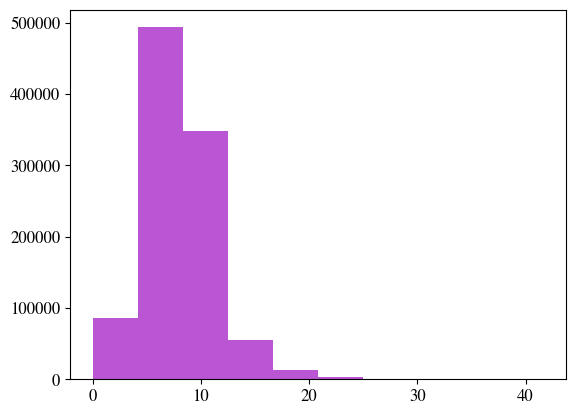

In [88]:
plt.figure()
plt.hist(test_bt_i[:,2].get())
plt.show()

In [85]:
xp.min(test_bt_i[:,2]),xp.max(test_bt_i[:,2])

(array(0.001), array(40.72078038))

In [94]:
test_prior_2.conditional_logpdf(test_bt_i).shape

(1000000, 4)

In [95]:
a = np.array([[0,0,0,1],[0,0,0,0]])

In [96]:
a.shape

(2, 4)

In [97]:
np.argmax(a)

3

In [98]:
a.flatten()[np.argmax(a)]

1

In [91]:
xp.argmax(xp.isinf(test_prior_2.conditional_logpdf(test_bt_i)))

array(2678899, dtype=int64)

In [100]:
2678896 % 4

0

In [101]:
test_bt_i.flatten()[2678899]

array(0.0001)

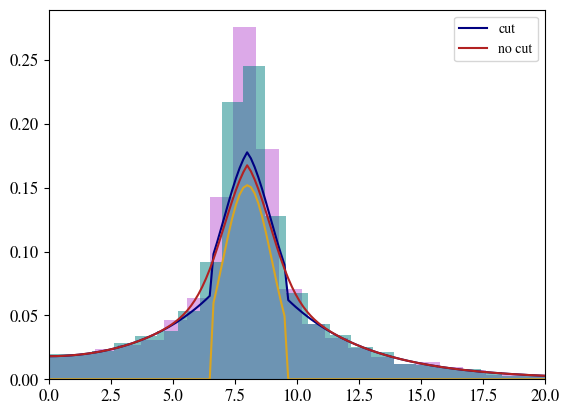

In [118]:
dx = np.linspace(0,30,200)
gdata = st.gaussian_exponential_mixture(test_rng,
                                        x0=8,
                                        disk_scale=3.31,
                                        bulge_scale=0.75,
                                        beta=0.33,
                                        bulge_cut=1.5).rvs(5000)
gdata_nc = st.gaussian_exponential_mixture(test_rng,
                                        x0=8,
                                        disk_scale=3.31,
                                        bulge_scale=0.75,
                                        beta=0.33,
                                        bulge_cut=None).rvs(5000)
plt.figure()
plt.hist(gdata.get(),density=True,alpha=0.5,bins=40)
plt.hist(gdata_nc.get(),density=True,alpha=0.5,bins=40)
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=3.31,
                                                   bulge_scale=1,
                                                   beta=0.33,
                                                   bulge_cut=1.5,
                                                   cast=True).logpdf(dx)),label='cut')
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=3.31,
                                                   bulge_scale=1,
                                                   beta=0.33,cast=True).logpdf(dx)),label='no cut')
plt.plot(dx,0.33*scst.truncnorm(loc=8,scale=1,a=-1.5,b=1.5).pdf(dx))
plt.legend()
plt.xlim(0,20)
plt.show()

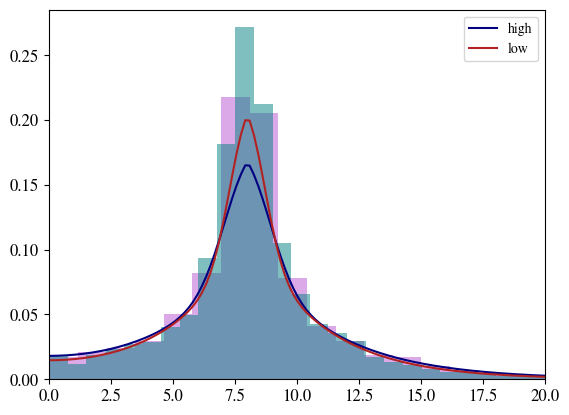

In [121]:
dx = np.linspace(0,35,200)
gdata = st.gaussian_exponential_mixture(test_rng,
                                        x0=8,
                                        disk_scale=3.31,
                                        bulge_scale=0.75,
                                        beta=0.33,
                                        bulge_cut=None).rvs(5000)
gdata_nc = st.gaussian_exponential_mixture(test_rng,
                                        x0=8,
                                        disk_scale=2.9,
                                        bulge_scale=0.75,
                                        beta=0.33,
                                        bulge_cut=None).rvs(5000)
plt.figure()
plt.hist(gdata.get(),density=True,alpha=0.5,bins=40)
plt.hist(gdata_nc.get(),density=True,alpha=0.5,bins=40)
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=3.31,
                                                   bulge_scale=1,
                                                   beta=0.33,
                                                   bulge_cut=None,
                                                   cast=True).logpdf(dx)),label='high')
plt.plot(dx,np.exp(st.gaussian_exponential_mixture(test_rng,
                                                   x0=8,
                                                   disk_scale=2.9,
                                                   bulge_scale=0.75,
                                                   beta=0.33,cast=True).logpdf(dx)),label='low')
# plt.plot(dx,0.33*scst.truncnorm(loc=8,scale=1,a=-1.5,b=1.5).pdf(dx))
plt.legend()
plt.xlim(0,20)
plt.show()

## Idea
At $r_{\rm cut}$, transition from bulge gaussian to disk exponential. Sampling from a "cored" exponential will be somewhat inefficient but not impossible. Accounting for the missing central density is straightforward, as the integral

$$\int_b^{+\infty} \frac{1}{a}e^{-x/a}  dx = -e^{-x/a}|_b^{+\infty} = 0 - - e^{-b/a} = e^{-b/a}$$

is tractable. 

Unfortunately, this still induces a sharp transition from disk to bulge.

In [126]:
xp.sum(xp.array([1]))

CUDARuntimeError: cudaErrorLaunchFailure: unspecified launch failure

In [128]:
sc.logsumexp([1,-np.inf])

1.0

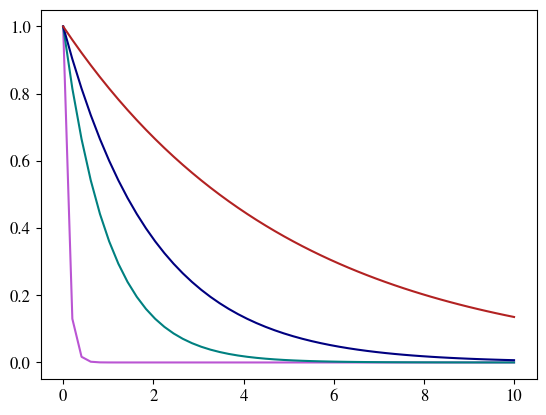

In [125]:
plt.figure()
xs = np.linspace(0,10)
for index in [0.1,1,2,5]:
    plt.plot(xs,np.exp(-xs/index))
plt.show()

In [101]:
Nsamp = 1000
likes = xp.empty(Nsamp)
draws = xp.empty((Nsamp,5))
for ii in range(Nsamp):
    draw = test_hprior.sample()
    draw['rh'] = pop_theta['rh']
    draw['bdq'] = pop_theta['bdq']
    test_prior_2.condition(draw)
    draws[ii,:] = xp.array([draw['m_mu'],draw['m_sigma'],draw['rh'],draw['bdq'],draw['a_alpha']]).flatten()
    likes[ii] = xp.sum(test_prior_2.conditional_logpdf(samps.T))

(array([  1.,   0.,   0.,   0.,   0.,   1.,   2.,  13.,  74., 909.]),
 array([-75422180.76764277, -68218574.83294997, -61014968.89825717,
        -53811362.96356437, -46607757.02887157, -39404151.09417877,
        -32200545.15948598, -24996939.22479318, -17793333.29010038,
        -10589727.35540758,  -3386121.42071477]),
 <BarContainer object of 10 artists>)

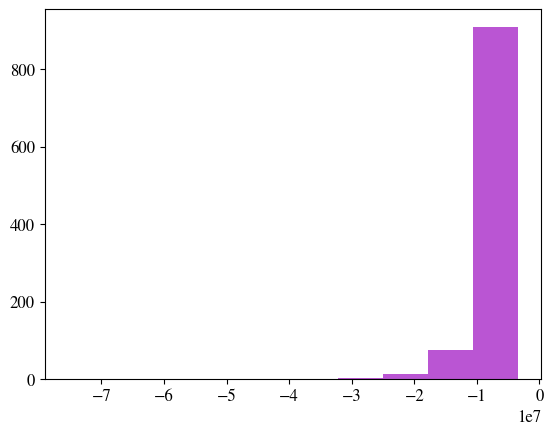

In [102]:
plt.hist(likes.get())

In [103]:
draws.shape

(1000, 5)

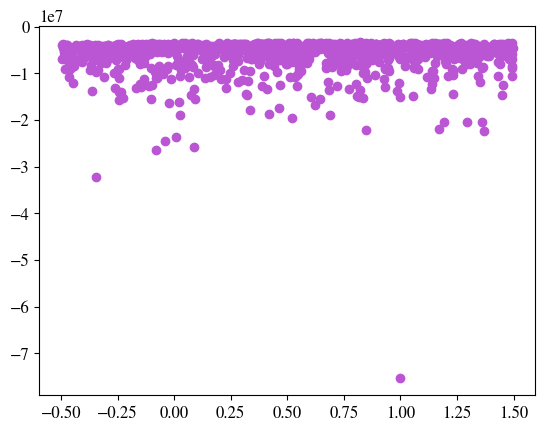

In [112]:
plt.figure()
plt.scatter(draws[:,4].get(),likes.get())
# plt.axvline(0.15,ls='--',c='k')
plt.show()

In [67]:
xp.argmax(likes)

array(264)

In [68]:
draws[xp.argmax(likes),:]

array([0.71258538, 0.72773218, 4.06758215, 0.145089  , 0.43590363])

In [69]:
pop_theta

{'m_mu': array([0.6]),
 'm_sigma': array([0.15]),
 'rh': array([3.31]),
 'bdq': array([0.33]),
 'a_alpha': array([0.5])}

In [70]:
arr_1 = xp.ones((10,2))
arr_2 = xp.ones((10,2))
arr_3 = xp.ones((10,2))

In [71]:
from cupyx.scipy import special as xsc

In [72]:
xp.array([arr_1,arr_2,arr_3]).shape

(3, 10, 2)

In [73]:
xsc.logsumexp(xp.array([arr_1,arr_2,arr_3]),axis=0)

array([[2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229],
       [2.09861229, 2.09861229]])

In [74]:
galcen = 8 #kpc
bulge_sigma = 2.1 ## kpc
rh = 2.9 # kpc
beta = 0.33 ## 2:1 disk mass to bulge mass
test_gal = st.gaussian_exponential_mixture(rng=test_rng,
                                           x0=galcen,
                                           disk_scale=rh,
                                           bulge_scale=bulge_sigma,
                                           beta=beta,
                                          cast=False)

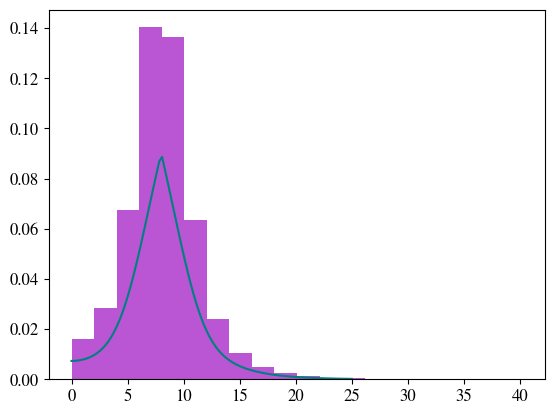

In [75]:
dls = np.linspace(0,25,100)
plt.figure()
plt.hist(test_gal.rvs(int(100000)).get(),density=True,bins=20)
plt.plot(dls, 2*np.exp(test_gal.logpdf(dls).get())/np.sum(np.exp(test_gal.logpdf(dls).get())),c='teal')
plt.show()

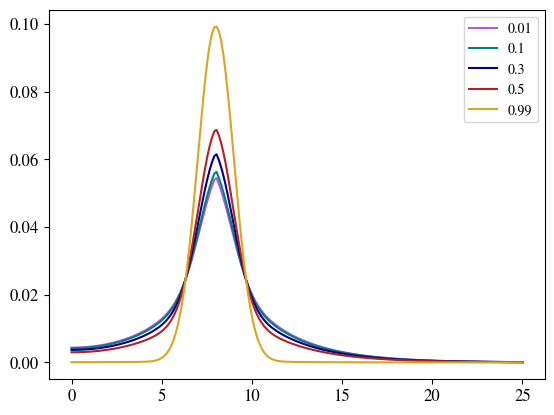

In [76]:
galcen = 8 #kpc
bulge_sigma = 1 ## kpc
rh = 2.9 # kpc
beta = 0.33 ## 2:1 disk mass to bulge mass
dls = np.linspace(0,25,200)
plt.figure()
for beta in [0.01,0.1,0.3,0.5,0.99]:
    test_gal = st.gaussian_exponential_mixture(rng=test_rng,
                                               x0=galcen,
                                               disk_scale=rh,
                                               bulge_scale=bulge_sigma,
                                               beta=beta,
                                              cast=False)
    # plt.hist(test_gal.rvs(int(100000)).get(),density=True,bins=20)
    plt.plot(dls, 2*np.exp(test_gal.logpdf(dls).get())/np.sum(np.exp(test_gal.logpdf(dls).get())),label=str(beta))
plt.legend()
plt.show()

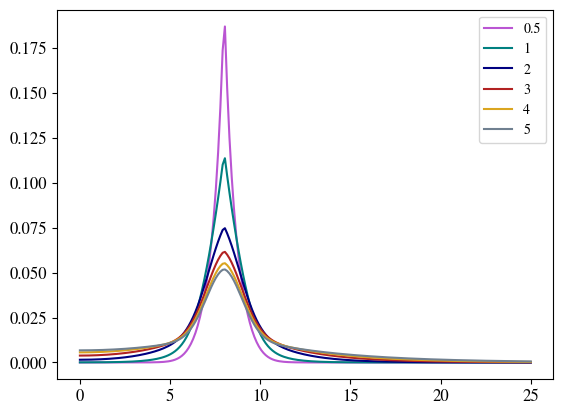

In [77]:
galcen = 8 #kpc
bulge_sigma = 1 ## kpc
rh = 2.9 # kpc
beta = 0.33 ## 2:1 disk mass to bulge mass
dls = np.linspace(0,25,200)
plt.figure()
for rh in [0.5,1,2,3,4,5]:
    test_gal = st.gaussian_exponential_mixture(rng=test_rng,
                                               x0=galcen,
                                               disk_scale=rh,
                                               bulge_scale=bulge_sigma,
                                               beta=beta,
                                              cast=False)
    # plt.hist(test_gal.rvs(int(100000)).get(),density=True,bins=20)
    plt.plot(dls, 2*np.exp(test_gal.logpdf(dls).get())/np.sum(np.exp(test_gal.logpdf(dls).get())),label=str(rh))
plt.legend()
plt.show()

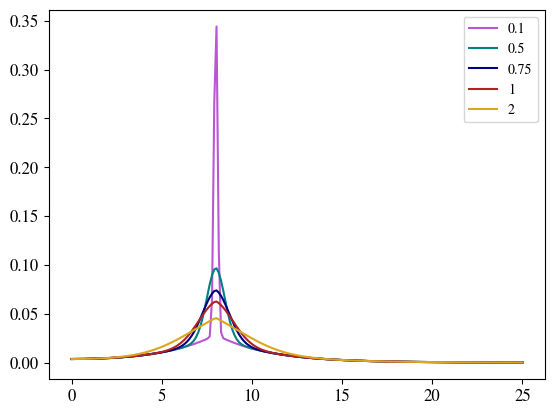

In [78]:
galcen = 8 #kpc
bulge_sigma = 1 ## kpc
rh = 2.9 # kpc
beta = 0.33 ## 2:1 disk mass to bulge mass
dls = np.linspace(0,25,200)
plt.figure()
for bulge_sigma in [0.1,0.5,0.75,1,2]:
    test_gal = st.gaussian_exponential_mixture(rng=test_rng,
                                               x0=galcen,
                                               disk_scale=rh,
                                               bulge_scale=bulge_sigma,
                                               beta=beta,
                                              cast=False)
    # plt.hist(test_gal.rvs(int(100000)).get(),density=True,bins=20)
    plt.plot(dls, 2*np.exp(test_gal.logpdf(dls).get())/np.sum(np.exp(test_gal.logpdf(dls).get())),label=str(bulge_sigma))
plt.legend()
plt.show()

In [16]:
amps, fgws = get_amp_freq(samps)

In [17]:
test_hprior = PopulationHyperPrior(test_rng)

In [18]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,2e-3,test_bin_width)
test_popmodel = PopModel(1e7,test_rng,hyperprior=test_hprior,Nsamp=1,Nreal=1,fbins=test_fbins)

In [19]:
test_f, test_fg, N_res = test_popmodel.run_model(pop_theta)

In [20]:
data_N_res, data_coarse_fg, data_res_idx = test_popmodel.thresher.serial_array_sort(xp.array([fgws,amps]),
                                                                                    test_popmodel.fbins,
                                                                                    snr_thresh=test_popmodel.thresh_val,
                                                                                    get_indices=True)
data_fg = test_popmodel.reweight_foreground(data_coarse_fg)[1:]

In [21]:
data_N_res

array(96)

In [22]:
len(data_res_idx)

96

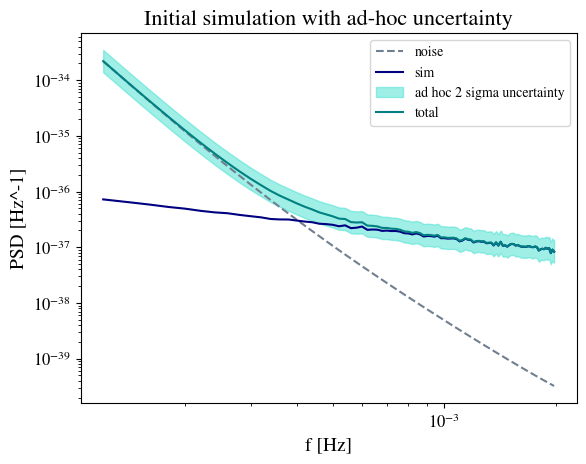

In [23]:
total_fs = test_f.get()
total_spec = data_fg.get() + lisa_noise_psd(test_f).get()
errs = 0.1
# errs = 1e-38
plt.figure()
plt.loglog(total_fs,lisa_noise_psd(test_f).get(),c='slategrey',ls='--',label='noise')
plt.loglog(total_fs,data_fg.get(),c='navy',label='sim')
plt.fill_between(total_fs,10**(np.log10(total_spec)-2*errs),10**(np.log10(total_spec)+2*errs),
                 color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
# plt.fill_between(total_fs,total_spec-2*errs,total_spec+2*errs,
#                  color='turquoise',alpha=0.5,label='ad hoc 2 sigma uncertainty')
plt.loglog(total_fs,total_spec,label='total',c='teal')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('PSD [Hz^-1]')
plt.title('Initial simulation with ad-hoc uncertainty')
# plt.ylim(1e-40,1e-36)
plt.show()

In [24]:
## ah, yes, I see the issue. Need to pull indices of res GBs from original threshing to assign params
## having done this, let's continue

In [25]:
samps.shape

(4, 5000000)

In [26]:
Ntheta = 4 # {m1,m2,dL,a}
gb_thetas = samps[:,data_res_idx].T
gb_thetas.shape

(96, 4)

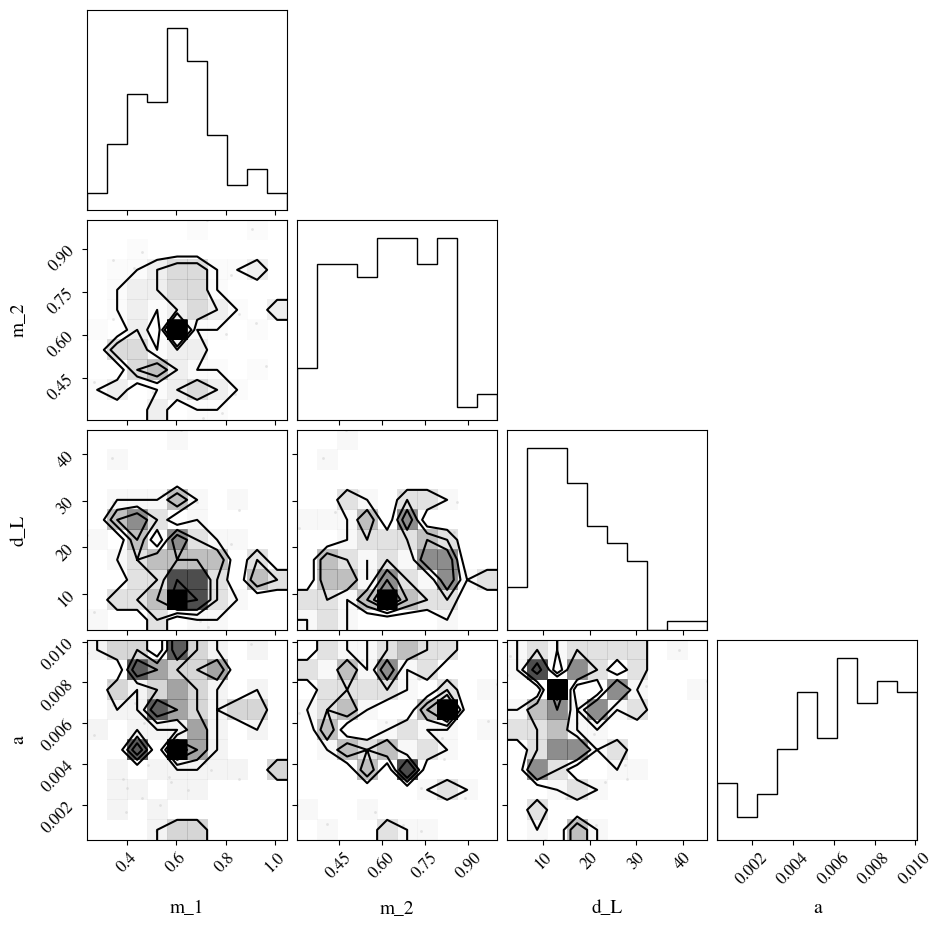

In [27]:
plt.close()
fig = corner(gb_thetas.get(),labels=list(test_prior.conditional_dict.keys()),bins=10)
plt.show()

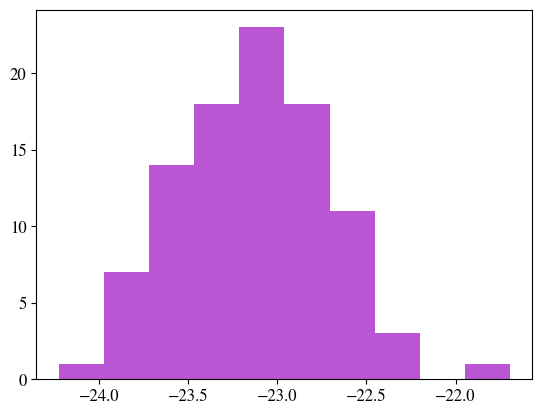

In [28]:
## for now, assume very simple covariance matrix scaled by amplitude
gb_amps = amps[data_res_idx]
plt.figure()
plt.hist(xp.log10(gb_amps).get())
plt.show()

Let the high-amplitude systems have extremely precise measurements, and scale from there:

In [29]:
scale_fac = xp.max(gb_amps)/xp.min(gb_amps)

In [30]:
scale_fac

array(337.51724669)

In [31]:
## scaled to mean of distribution
scaled_amps = gb_amps/xp.mean(gb_amps)

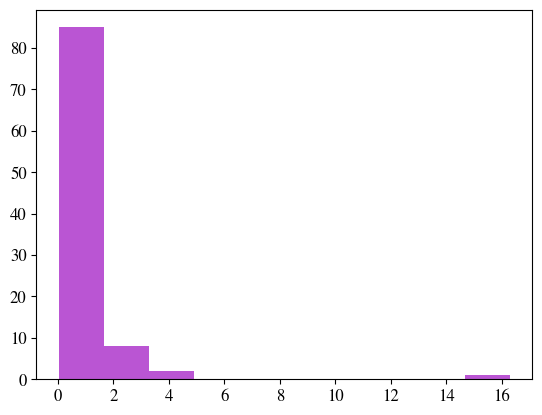

In [32]:
plt.figure()
plt.hist(scaled_amps.get())
plt.show()

In [33]:
xp.max(scaled_amps), xp.min(scaled_amps)

(array(16.28455586), array(0.04824807))

In [34]:
## assume 10% fractional error on average source and scale from there
frac_err = 0.1* 1/scaled_amps

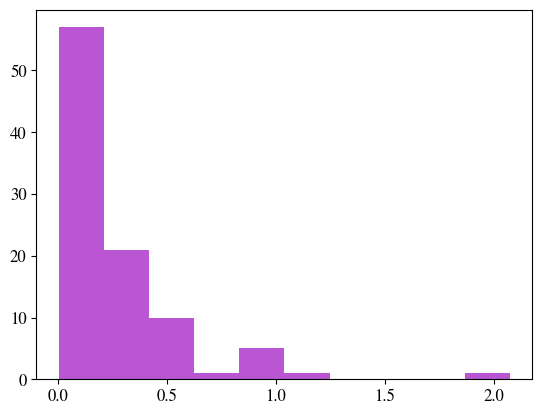

In [35]:
plt.figure()
plt.hist(frac_err.get())
plt.show()

In [36]:
## construct covariances, with scaling factors for each parameter
m_scale = 0.5 ## reduced error on masses
d_scale = 2 ## more error on distances
a_scale = 0.01 ## greatly reduced error on orbital separation

## apply covariances
scale_cov = xp.array([[m_scale,0.5,1,0.05],
                      [0.5,m_scale,1,0.05],
                      [1.0,1.0,d_scale,0.01],
                      [0.05,0.05,0.01,a_scale]])
scale_cov = xp.diag([m_scale,m_scale,d_scale,a_scale])

theta_cov = frac_err.reshape((frac_err.size,1,1)) * scale_cov

In [37]:
scale_cov

array([[0.5 , 0.  , 0.  , 0.  ],
       [0.  , 0.5 , 0.  , 0.  ],
       [0.  , 0.  , 2.  , 0.  ],
       [0.  , 0.  , 0.  , 0.01]])

In [38]:
## clean up memory
del frac_err
del scaled_amps
del gb_amps

In [39]:
theta_cov.shape

(96, 4, 4)

In [40]:
xp.max(theta_cov)

array(4.1452435)

In [41]:
theta_cov

array([[[3.40708085e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 3.40708085e-02, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.36283234e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.81416171e-04]],

       [[9.41120003e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 9.41120003e-02, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.76448001e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.88224001e-03]],

       [[2.55675153e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 2.55675153e-01, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.02270061e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.11350306e-03]],

       ...,

       [[1.57992593e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000

Moving the orbital separation to log space:

In [42]:
gb_thetas[:,-1] = xp.log10(gb_thetas[:,-1])

In [43]:
## setup w.r.t. the data
datadict = {'fs':test_f,
            'fg':data_fg,
            'fg_sigma':xp.array(errs),
            'Nres':data_N_res,
            'noise':lisa_noise_psd(test_f),
            'gb_thetas':gb_thetas,
            'gb_cov':theta_cov}

In [44]:
test_rng = xp.random.default_rng(42)

In [45]:
translation_dict = {0:'m_mu',
                    1:'m_sigma',
                    2:'d_gamma_a',
                    3:'d_gamma_b',
                    4:'a_alpha'}
## starting with the broader priors
eryn_hyperprior_dict = {0:st.uniform(test_rng,loc=0.2,scale=0.9,cast=True),
                        1:st.invgamma(test_rng,5,cast=True),
                        2:st.uniform(test_rng,loc=1,scale=10,cast=True), ## these are pretty arbitrary
                        3:st.uniform(test_rng,loc=1,scale=10,cast=True), ## these are pretty arbitrary
                        4:st.uniform(test_rng,loc=-0.5,scale=2,cast=True)}
eryn_trans_dict = {translation_dict[key]:eryn_hyperprior_dict[key] for key in eryn_hyperprior_dict.keys()}

In [46]:
eryn_trans_dict

{'m_mu': <distributions.uniform at 0x78f07c45c890>,
 'm_sigma': <distributions.invgamma at 0x78f08e750e30>,
 'd_gamma_a': <distributions.uniform at 0x78f07c45f920>,
 'd_gamma_b': <distributions.uniform at 0x78f07c563980>,
 'a_alpha': <distributions.uniform at 0x78f08e656270>}

In [47]:
eryn_prior = ProbDistContainer(eryn_hyperprior_dict)

In [48]:
Nreal = 2

In [49]:
new_rng = xp.random.default_rng(1)

In [101]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,2e-3,test_bin_width)
eryn_popmodel = PopModel(1e7,new_rng,hyperprior=eryn_trans_dict,fbins=test_fbins,Nreal=Nreal)

In [102]:
test_theta = {'m_mu':xp.array([0.3]),'m_sigma':xp.array([0.8]),
             # 'd_mu':xp.array([30]),'d_sigma':xp.array([10]),
             'd_gamma_a':xp.array([5]),'d_gamma_b':xp.array([3]),
             'a_alpha':xp.array([0.9])}

In [103]:
test_f, test_draw_spec, test_draw_N = eryn_popmodel.run_model(test_theta)

In [104]:
eryn_popmodel.construct_likelihood(datadict,hp_beta=0.05,hp_alpha=5)

got here


In [105]:
log_like_fn = eryn_popmodel.pop_ln_prob

In [106]:
test_draw_spec.shape

(94, 2, 1)

In [107]:
datadict['noise'].shape

(94,)

In [108]:
test_f.shape

(94,)

In [109]:
datadict['fs'].shape

(94,)

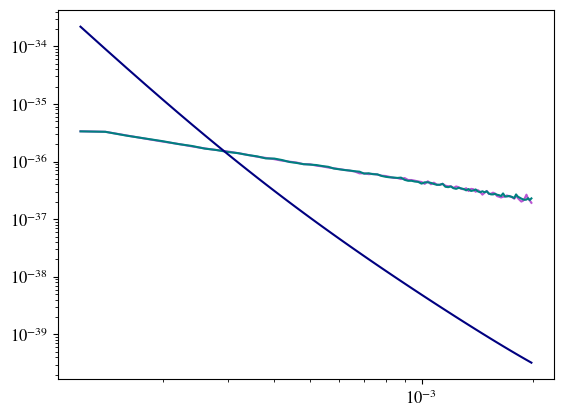

In [110]:
plt.figure()
plt.loglog(test_f.get(),test_draw_spec.squeeze().get())
plt.loglog(test_f.get(),datadict['noise'].get())
plt.show()

In [111]:
# for fi in [1,25,50,100,200,240]:
#     plt.figure()
#     # test_Nr = 5
#     # ta = xp.logspace(-42,-32,100)
#     ta = eryn_popmodel.fg_like.cgrid.squeeze()
#     # mu_test = lisa_noise_psd(test_f)
#     # alpha_test = 1e-40
#     # beta_test = 0.1*lisa_noise_psd(test_f)
#     # print(ta.shape)
    
#     eryn_popmodel.fg_like.conditional_t.update(test_draw_spec+eryn_popmodel.fg_like.noise_psd[:,None,None])
#     logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
#     logpos = xp.sum(sc.logsumexp(logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get()))
#     plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
#     plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
#     plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
#     for i in range(5):
#         plt.axvline(test_draw_spec[fi,i,0].get()+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
#     plt.xlabel('PSD value')
#     plt.ylabel('log p')
#     plt.xscale('log')
#     plt.ylim(-100,50)
#     plt.xlim(1e-38,1e-33)
#     plt.title("f={:0.2e} Hz, logpos={:0.2e}".format(test_f.get()[fi],logpos))
#     plt.legend()
#     plt.show()

In [112]:
ndim = len(eryn_popmodel.hyperprior.hyperprior_dict)
nwalkers = 10
ntemps = 1

In [113]:
# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps)

In [114]:
## MH with prior draws as the proposal function
PriorMove = make_PriorMove(eryn_prior)
# PriorMove = DistributionGenerate({'model_0':eryn_prior})

Set up the branch supplemental to track the foreground spectra and number of resolved binaries:

In [115]:
branch_supp = BranchSupplemental(
    {"spectra": np.zeros((ntemps,nwalkers,1,len(test_f),Nreal,1)),
     "Nres": np.zeros((ntemps,nwalkers,1,1,Nreal,1))},
    base_shape=(ntemps, nwalkers,1),
    copy=True
)

In [116]:
# starting positions
# randomize throughout prior
coords = eryn_prior.rvs(size=(ntemps,nwalkers,))

Because we are now including the branch supplemental, we need to make a starting State object.

In [117]:
start_state = State(coords,
                    branch_supplemental={'model_0':branch_supp})

Initialize the new supplemental backend. Need to provide the supplemental names and dims.

In [118]:
supp_dims = {'spectra':(len(test_f),Nreal,1),
             'Nres':(1,Nreal,1)}
supp_backend = SupplementalBackend(supp_dims)

Build an Eryn ensemble with the added branch supplemental and backend.

In [119]:
ensemble = EnsembleSampler(nwalkers,
                           ndim,
                           log_like_fn,
                           eryn_prior,
                           # moves=[(StretchMove(a=a),0.7),(PriorMove,0.1),(PoissonMove(),0.2)],
                           # moves=
                           moves=StretchMove(),
                           track_moves=True,
                           tempering_kwargs=tempering_kwargs,
                           provide_supplemental=True,
                           dynamic_branch_supplemental=True,
                           backend=supp_backend
                          )

In [120]:
xp.cuda.is_available()

True

In [121]:
ensemble.provide_supplemental

True

In [122]:
nsteps = 5
burn = None
thin_by = 1
out = ensemble.run_mcmc(start_state, nsteps, burn=burn, progress=True, thin_by=thin_by)
# pool.close()
# pool.join()

got here
got here
got here
got here
got here
got here
got here
got here
got here
got here


  0%|                                                                                                                                                        | 0/5 [00:00<?, ?it/s]

got here
got here
got here
got here
got here


 20%|████████████████████████████▊                                                                                                                   | 1/5 [00:02<00:11,  2.79s/it]

got here
got here
got here
got here
got here
got here


...

got here
got here
got here
got here
got here
got here
got here


 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 4/5 [00:11<00:02,  2.90s/it]

got here
got here
got here
got here
got here
got here
got here
got here
got here


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:15<00:00,  3.08s/it]

got here


In [123]:
ensemble.acceptance_fraction

array([[0.6, 0.2, 0.4, 0.4, 0.2, 0.2, 0.2, 0.4, 0.6, 0.4]])

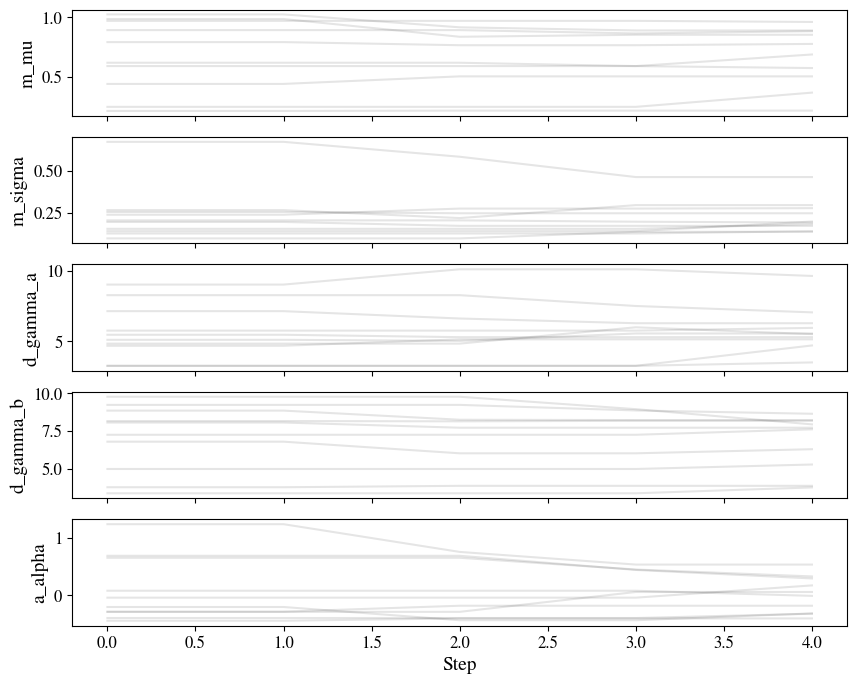

In [124]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

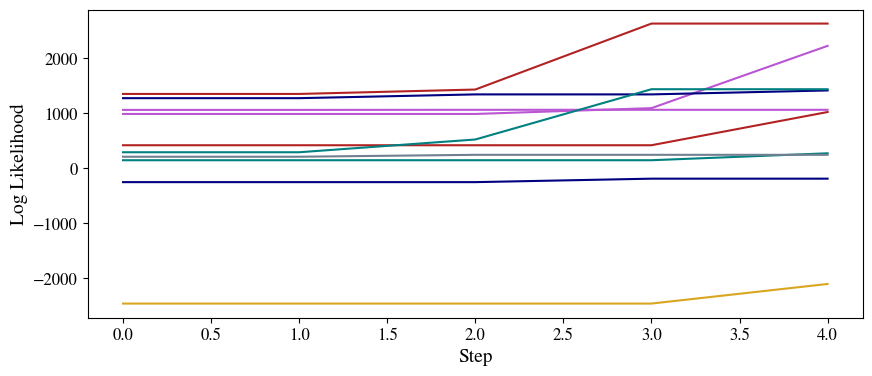

In [125]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

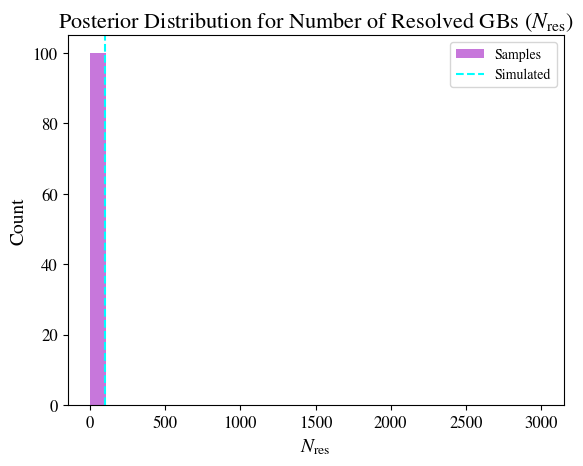

In [126]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),temp_index=0)#,showtrue=False)

Starting spectra:

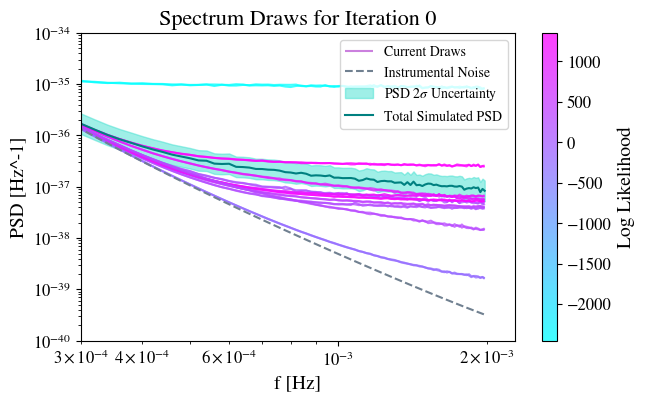

In [127]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(3e-4,),ylim=(1e-40,1e-34),iteration=0)

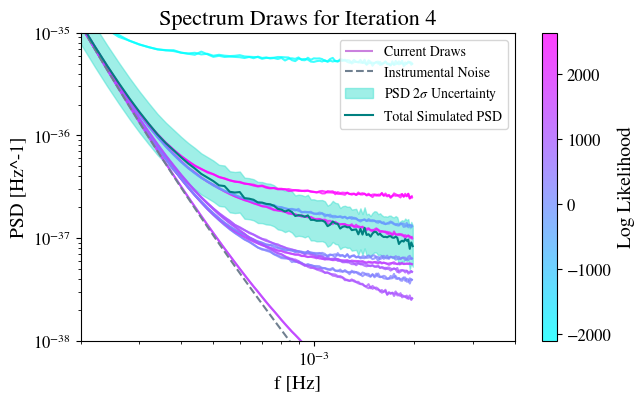

In [128]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,4e-3),ylim=(1e-38,1e-35),iteration=4)

In [129]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [130]:
spec_chain[-1,...].shape

(10, 94, 2)

IndexError: index 2 is out of bounds for axis 1 with size 2

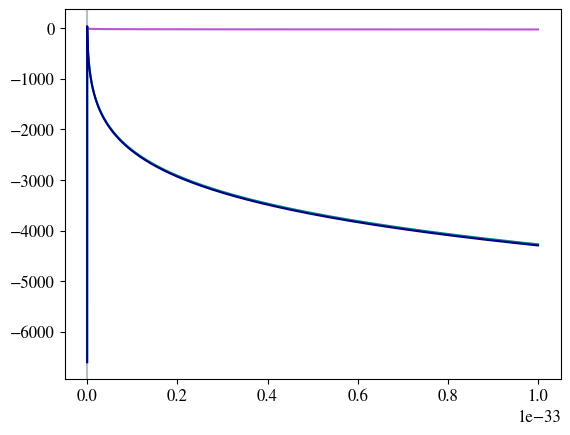

In [132]:
for ti in range(10):
    current_draw = spec_chain[-1,ti,...]
    for fi in [90]:
        plt.figure()
        # test_Nr = 5
        # ta = xp.logspace(-42,-32,100)
        ta = eryn_popmodel.fg_like.cgrid.squeeze()
        # mu_test = lisa_noise_psd(test_f)
        # alpha_test = 1e-40
        # beta_test = 0.1*lisa_noise_psd(test_f)
        # print(ta.shape)
        
        eryn_popmodel.fg_like.conditional_t.update(xp.array(current_draw)[...,xp.newaxis]+\
                                                   eryn_popmodel.fg_like.noise_psd[:,None,None])
        logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
        plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
        plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
        plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
        for i in range(5):
            plt.axvline(current_draw[fi,i]+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
        plt.xlabel('PSD value')
        plt.ylabel('log p')
        plt.xscale('log')
        plt.ylim(-100,50)
        plt.xlim(1e-40,1e-33)
        plt.title("w{} at f={:0.2e} Hz".format(ti,test_f.get()[fi]))
        plt.legend()
        plt.show()

In [133]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [134]:
samples = ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

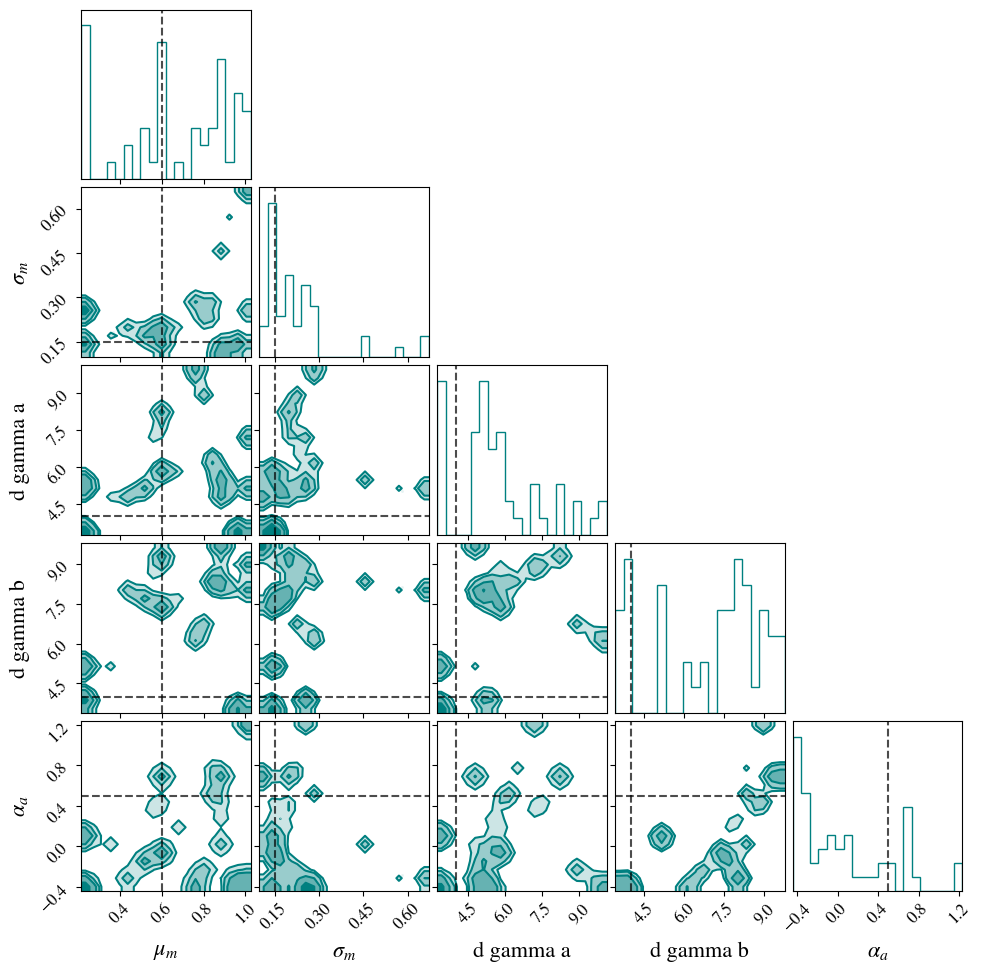

In [135]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

Current spectra:

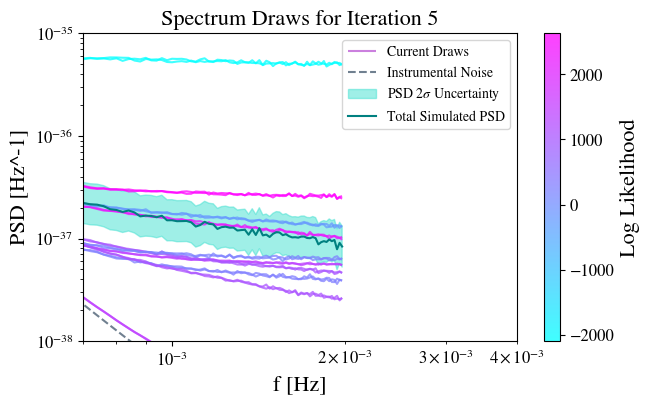

In [136]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(7e-4,4e-3),ylim=(1e-38,1e-35),iteration=-1)

In [137]:
nsteps = 20
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:21<00:00,  4.07s/it]


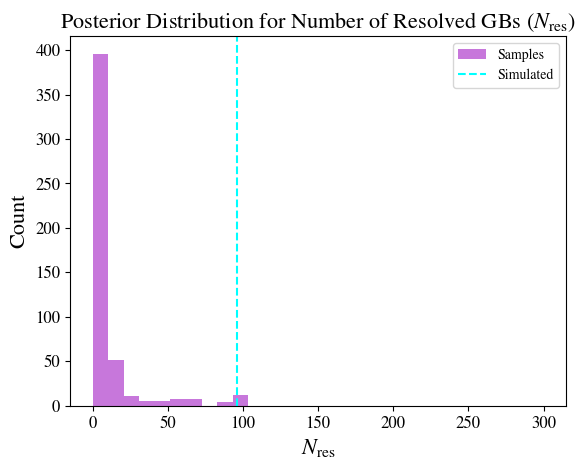

In [149]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,300,30),
               discard=0,thin=1,temp_index=0)#,showtrue=False)

In [139]:
ensemble.acceptance_fraction

array([[0.28, 0.32, 0.28, 0.24, 0.2 , 0.48, 0.36, 0.44, 0.4 , 0.2 ]])

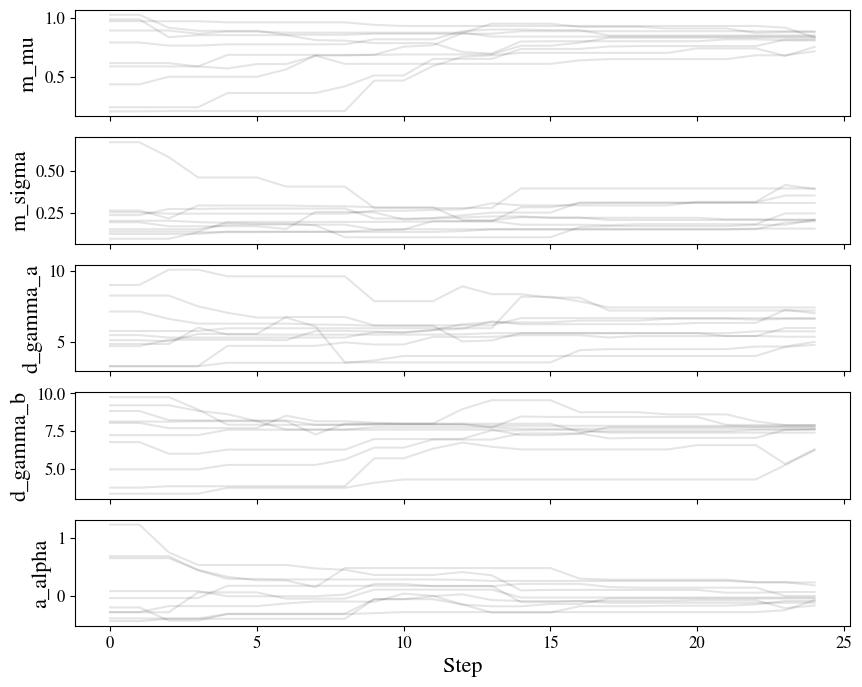

In [140]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

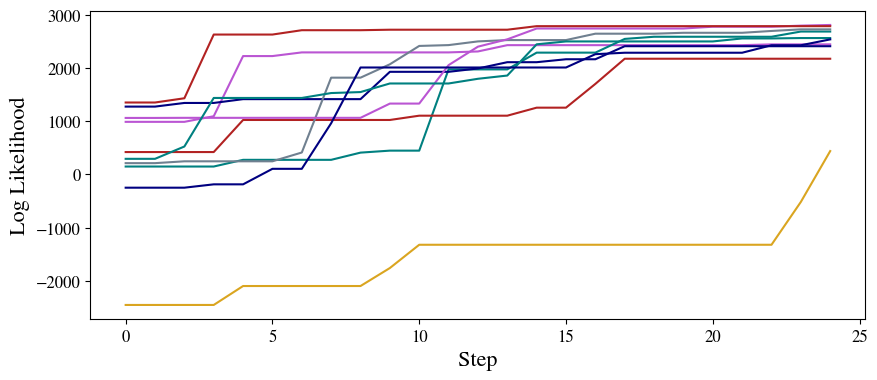

In [141]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

In [142]:
ensemble.get_autocorr_time()

{'model_0': array([[3.77475828e-16, 3.33066907e-16, 3.33066907e-16, 5.10702591e-16,
         2.33146835e-16]])}

In [143]:
tll = ensemble.get_log_like()

In [144]:
tll = tll.squeeze()

In [145]:
diff = tll[1:,:] - tll[:-1,:]

In [146]:
np.argwhere(diff<0)

array([[3, 8]])

Where are they now?

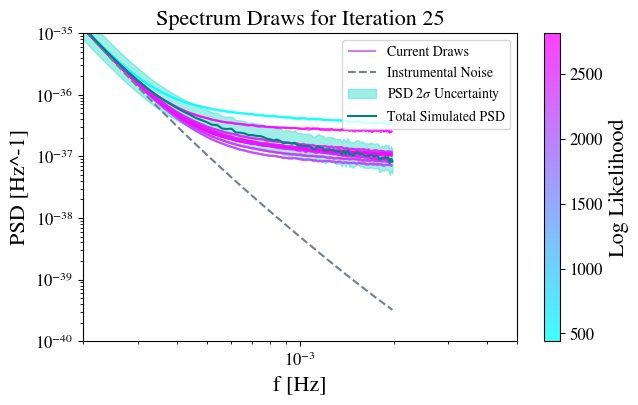

In [147]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,5e-3),ylim=(1e-40,1e-35),iteration=-1)

In [148]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [ ]:
for ti in range(10):
    current_draw = spec_chain[-1,ti,...]
    for fi in [200]:
        plt.figure()
        # test_Nr = 5
        # ta = xp.logspace(-42,-32,100)
        ta = eryn_popmodel.fg_like.cgrid.squeeze()
        # mu_test = lisa_noise_psd(test_f)
        # alpha_test = 1e-40
        # beta_test = 0.1*lisa_noise_psd(test_f)
        # print(ta.shape)
        
        eryn_popmodel.fg_like.conditional_t.update(xp.array(current_draw)[...,xp.newaxis]+\
                                                   eryn_popmodel.fg_like.noise_psd[:,None,None])
        logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
        plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
        plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
        plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
        for i in range(5):
            plt.axvline(current_draw[fi,i]+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
        plt.xlabel('PSD value')
        plt.ylabel('log p')
        plt.xscale('log')
        plt.ylim(-100,50)
        plt.xlim(1e-40,1e-33)
        plt.title("w{} at f={:0.2e} Hz".format(ti,test_f.get()[fi]))
        plt.legend()
        plt.show()

In [150]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [151]:
truths

array([0.6 , 0.15, 4.  , 4.  , 0.5 ])

In [152]:
samples = ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

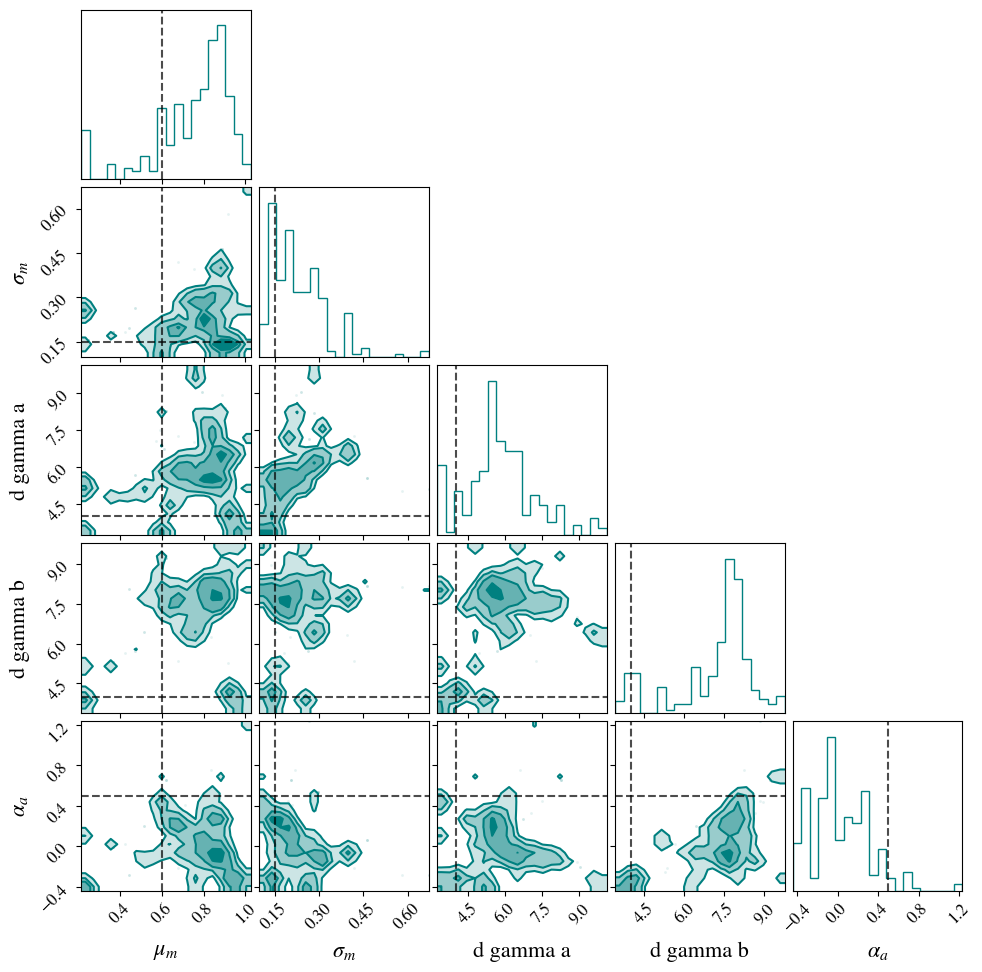

In [153]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [154]:
np.var(ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'][...,4],axis=0)

array([[0.0195393 ],
       [0.00619445],
       [0.01596493],
       [0.01809939],
       [0.00370927],
       [0.00675933],
       [0.02610964],
       [0.10655117],
       [0.02106904],
       [0.01257726]])

In [ ]:
nsteps = 20
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)

In [ ]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),
               discard=20,thin=1,temp_index=0)#,showtrue=False)

In [ ]:
ensemble.acceptance_fraction

In [ ]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

In [ ]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0,ylim=(8000,11000))

In [ ]:
ensemble.get_autocorr_time(discard=20)

In [ ]:
tll = ensemble.get_log_like()

In [ ]:
tll = tll.squeeze()

In [ ]:
diff = tll[1:,:] - tll[:-1,:]

In [ ]:
np.argwhere(diff<0)

Where are they now?

In [ ]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,5e-3),ylim=(1e-40,1e-35),iteration=-1)

In [ ]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [ ]:
for ti in range(10):
    current_draw = spec_chain[-1,ti,...]
    for fi in [200]:
        plt.figure()
        # test_Nr = 5
        # ta = xp.logspace(-42,-32,100)
        ta = eryn_popmodel.fg_like.cgrid.squeeze()
        # mu_test = lisa_noise_psd(test_f)
        # alpha_test = 1e-40
        # beta_test = 0.1*lisa_noise_psd(test_f)
        # print(ta.shape)
        
        eryn_popmodel.fg_like.conditional_t.update(xp.array(current_draw)[...,xp.newaxis]+\
                                                   eryn_popmodel.fg_like.noise_psd[:,None,None])
        logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
        plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
        plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
        plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
        for i in range(5):
            plt.axvline(current_draw[fi,i]+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
        plt.xlabel('PSD value')
        plt.ylabel('log p')
        plt.xscale('log')
        plt.ylim(-100,50)
        plt.xlim(1e-40,1e-33)
        plt.title("w{} at f={:0.2e} Hz".format(ti,test_f.get()[fi]))
        plt.legend()
        plt.show()

In [ ]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [ ]:
truths

In [ ]:
samples = ensemble.get_chain(discard=20,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

In [ ]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [ ]:
np.var(ensemble.get_chain(discard=20,temp_index=0,thin=1)['model_0'][...,4],axis=0)

In [ ]:
nsteps = 20
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)

In [ ]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),
               discard=20,thin=1,temp_index=0)#,showtrue=False)

In [ ]:
ensemble.acceptance_fraction

In [ ]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

In [ ]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0,ylim=(8000,11000))

In [ ]:
ensemble.get_autocorr_time()

In [ ]:
tll = ensemble.get_log_like()

In [ ]:
tll = tll.squeeze()

In [ ]:
diff = tll[1:,:] - tll[:-1,:]

In [ ]:
np.argwhere(diff<0)

Where are they now?

In [ ]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,5e-3),ylim=(1e-40,1e-35),iteration=-1)

In [ ]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [ ]:
for ti in range(10):
    current_draw = spec_chain[-1,ti,...]
    for fi in [200]:
        plt.figure()
        # test_Nr = 5
        # ta = xp.logspace(-42,-32,100)
        ta = eryn_popmodel.fg_like.cgrid.squeeze()
        # mu_test = lisa_noise_psd(test_f)
        # alpha_test = 1e-40
        # beta_test = 0.1*lisa_noise_psd(test_f)
        # print(ta.shape)
        
        eryn_popmodel.fg_like.conditional_t.update(xp.array(current_draw)[...,xp.newaxis]+\
                                                   eryn_popmodel.fg_like.noise_psd[:,None,None])
        logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
        plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
        plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
        plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
        for i in range(5):
            plt.axvline(current_draw[fi,i]+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
        plt.xlabel('PSD value')
        plt.ylabel('log p')
        plt.xscale('log')
        plt.ylim(-100,50)
        plt.xlim(1e-40,1e-33)
        plt.title("w{} at f={:0.2e} Hz".format(ti,test_f.get()[fi]))
        plt.legend()
        plt.show()

In [ ]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [ ]:
truths

In [ ]:
samples = ensemble.get_chain(discard=40,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

In [ ]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [ ]:
np.var(ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'][...,4],axis=0)

In [ ]:
nsteps = 20
burn = None
thin_by = 1
out = ensemble.run_mcmc(out, nsteps, burn=burn, progress=True, thin_by=thin_by)

In [ ]:
plot_Nres_hist(ensemble,datadict,bins=np.linspace(0,3000,30),
               discard=20,thin=1,temp_index=0)#,showtrue=False)

In [ ]:
ensemble.acceptance_fraction

In [ ]:
plot_model_chains(ensemble,names=eryn_popmodel.hpar_names,temp_index=0)

In [ ]:
plot_model_loglikes(ensemble,names=eryn_popmodel.hpar_names,temp_index=0,ylim=(8000,11000))

In [ ]:
ensemble.get_autocorr_time()

In [ ]:
tll = ensemble.get_log_like()

In [ ]:
tll = tll.squeeze()

In [ ]:
diff = tll[1:,:] - tll[:-1,:]

In [ ]:
np.argwhere(diff<0)

Where are they now?

In [ ]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,5e-3),ylim=(1e-40,1e-35),iteration=-1)

In [ ]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [ ]:
for ti in range(10):
    current_draw = spec_chain[-1,ti,...]
    for fi in [200]:
        plt.figure()
        # test_Nr = 5
        # ta = xp.logspace(-42,-32,100)
        ta = eryn_popmodel.fg_like.cgrid.squeeze()
        # mu_test = lisa_noise_psd(test_f)
        # alpha_test = 1e-40
        # beta_test = 0.1*lisa_noise_psd(test_f)
        # print(ta.shape)
        
        eryn_popmodel.fg_like.conditional_t.update(xp.array(current_draw)[...,xp.newaxis]+\
                                                   eryn_popmodel.fg_like.noise_psd[:,None,None])
        logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
        plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
        plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
        plt.plot(ta.get(),logpdf[fi,:]+eryn_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
        for i in range(5):
            plt.axvline(current_draw[fi,i]+eryn_popmodel.fg_like.noise_psd.get()[fi],c='slategrey',alpha=0.3,zorder=-10)
        plt.xlabel('PSD value')
        plt.ylabel('log p')
        plt.xscale('log')
        plt.ylim(-100,50)
        plt.xlim(1e-40,1e-33)
        plt.title("w{} at f={:0.2e} Hz".format(ti,test_f.get()[fi]))
        plt.legend()
        plt.show()

In [ ]:
injdict = pop_theta
truths = xp.asnumpy([injdict[key].get() for key in injdict.keys()]).flatten()

In [ ]:
truths

In [ ]:
samples = ensemble.get_chain(discard=50,temp_index=0,thin=1)['model_0'].reshape(-1,ndim)

In [ ]:
plot_corners(samples,parameters=[r'$\mu_m$',r'$\sigma_m$',r'd gamma a',r'd gamma b',r'$\alpha_a$'],
             Nbins=20,figsize=(10,10),truths=truths,density=False,plot_datapoints=True
             )

In [ ]:
np.var(ensemble.get_chain(discard=0,temp_index=0,thin=1)['model_0'][...,4],axis=0)

In [ ]:
plot_spectra(ensemble,datadict,chain_kwargs=dict(temp_index=0),
             xlim=(2e-4,4e-3),ylim=(1e-38,1e-35),iteration=20)

In [ ]:
spec_chain = ensemble.get_chain_supplemental(temp_index=0)['model_0']['spectra'].squeeze()

In [ ]:
spec_chain.shape

In [ ]:
from copy import deepcopy

In [ ]:
total_fs.shape

In [ ]:
eryn_popmodel.fg_like.ln_pgrid.shape

In [ ]:
ll = eryn_popmodel.fg_like
ll.vector_gaussian_logpdf(ll.cgrid[0,:][xp.newaxis,:],ll.mu_vec[0],xp.atleast_1d(ll.cov)[0])[xp.newaxis,:].shape

In [ ]:
test_draw_spec = spec_chain[-1,0,...]
test_draw_spec = xp.array(test_draw_spec)[...,xp.newaxis]

In [ ]:
ll.ln_prob_conditional_like(test_draw_spec)

In [ ]:
ll.ln_pgrid = ll.vector_gaussian_logpdf(ll.cgrid[0,:][xp.newaxis,:],ll.mu_vec[0],xp.atleast_1d(ll.cov)[0])[xp.newaxis,:]

In [ ]:
ll.ln_pgrid.shape

In [ ]:
ll.cgrid[0].shape

In [ ]:
ll.ln_prob_conditional_like(test_draw_spec)

Okay that's one problem solved.

Now let's broaden the grid and switch to integration over log10Sgw.

$d\ln(x) = \frac{dx}{x}$, so

$\int f(x) dx = \int f(x) x d\ln(x)$

For $\log_{10}$, this is:

$d\log_{10}(x) = \frac{dx}{x\ln10}$, so

$\int f(x) dx = \ln10 \int f(x) x d\log_{10}(x)$

We can neglect this factor of x if we pass f(x) as a lognormal pdf without the 1/x leading factor.

In [ ]:
new_cgrid = xp.logspace(-42,-33,1000)

In [ ]:
def grid_gaussian_logpdf(theta_vec, mu_vec, sigma):
    """
    Array operation-based Gaussian log PDF, sans normalization.

    Parameters
    ----------
    theta_vec : array
        Grid of proposed (model) spectra. Must be an array whose leading axis is frequency.
    mu_vec : array
        Measured (data) spectrum. Will be cast to shape (Nf,1). Leading axis must be of same size as theta_vec.
    sigma : float or array
        Uncertainty of the Gaussian as standard deviation. If array, designates uncertainty in each
        frequency bin, and must be of same shape as mu_vec.

    Returns
    -------
    logpdf
        Unnormalized Gaussian log likelihood.

    """
    
    ## force proper casting
    theta_vec = xp.atleast_1d(theta_vec)
    mu_vec = xp.atleast_1d(mu_vec)
    sigma = xp.atleast_1d(sigma)
    if theta_vec.ndim == 1:
        theta_vec = theta_vec[:,xp.newaxis]
    if mu_vec.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-mu_vec.ndim):
            mu_vec = mu_vec[...,xp.newaxis]
    if sigma.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-sigma.ndim):
            sigma = sigma[...,xp.newaxis]
            

    return - (theta_vec - mu_vec)**2/(2*sigma**2)

def grid_lognormal_logpdf(theta_vec, mu_vec, sigma):
    """
    Array operation-based log normal log PDF, sans normalization.

    Note that this does not include a leading factor of 1/x, as we integrate over 
    a log-spaced grid and it would cancel out there.

    Parameters
    ----------
    theta_vec : array
        Grid of proposed (model) spectra. Must be an array whose leading axis is frequency.
    mu_vec : array
        Measured (data) spectrum. Will be cast to shape (Nf,1). Leading axis must be of same size as theta_vec.
    sigma : float or array
        Uncertainty of the Gaussian as standard deviation. If array, designates uncertainty in each
        frequency bin, and must be of same shape as mu_vec.

    Returns
    -------
    logpdf
        Unnormalized Gaussian log likelihood.

    """
    
    ## force proper casting
    theta_vec = xp.atleast_1d(theta_vec)
    mu_vec = xp.atleast_1d(mu_vec)
    sigma = xp.atleast_1d(sigma)
    if theta_vec.ndim == 1:
        theta_vec = theta_vec[:,xp.newaxis]
    if mu_vec.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-mu_vec.ndim):
            mu_vec = mu_vec[...,xp.newaxis]
    if sigma.ndim < theta_vec.ndim:
        for i in range(theta_vec.ndim-sigma.ndim):
            sigma = sigma[...,xp.newaxis]
            

    return - (xp.log(theta_vec) - xp.log(mu_vec))**2/(2*sigma**2)

In [ ]:
new_logpdf = grid_gaussian_logpdf(new_cgrid[xp.newaxis,:],ll.mu_vec,xp.atleast_1d(ll.cov))

In [ ]:
logn_logpdf = grid_lognormal_logpdf(new_cgrid[xp.newaxis,:],ll.mu_vec,0.2)

In [ ]:
fi = 100

In [ ]:
plt.figure()
for fi in [0,50,100,150,200]:
    # plt.plot(new_cgrid.get(),new_logpdf[fi,:].get(),
    #          label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
    plt.plot(new_cgrid.get(),np.exp(logn_logpdf[fi,:].get()),
             label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
# for i in range(5):
#     plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('p')
plt.xscale('log')
# plt.ylim(-0.5e73,0)
# plt.xlim(1e-38,1e-33)
# plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

In [ ]:
plt.figure()
for fi in [0,50,100,150,200]:
    # plt.plot(new_cgrid.get(),new_logpdf[fi,:].get(),
    #          label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
    plt.plot(new_cgrid.get(),logn_logpdf[fi,:].get(),
             label="f={:0.2e} Hz".format(test_f.get()[fi])) #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
# for i in range(5):
#     plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
# plt.ylim(-0.5e73,0)
# plt.xlim(1e-38,1e-33)
# plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

In [ ]:
ta = new_cgrid

plt.figure()

eryn_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(0,100)
plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

Much better coverage, good.

Now let's look at the convoluton:

In [ ]:
from cupyx.scipy import special as xsc

In [ ]:
logpdf.shape, logn_logpdf.shape

In [ ]:
convolved_loglike_of_f = xsc.logsumexp(xp.array(logpdf)+xp.array(logn_logpdf),axis=1)

In [ ]:
plt.figure()
plt.plot(total_fs,convolved_loglike_of_f.get())
plt.xscale('log')
plt.show()

In [ ]:
plt.figure()
plt.plot(ta.get(),logn_logpdf[fi,:].get(),label='loglike')
plt.plot(ta.get(),logpdf[fi,:]+logn_logpdf[fi,:].get(),label='posterior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3)
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
# plt.ylim(40,85)
# plt.xlim(1e-37,1e-36)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.plot(ta.get(),np.logaddexp.accumulate(logn_logpdf[fi,:].get()),label='loglike')
plt.plot(ta.get(),np.logaddexp.accumulate(logpdf[fi,:]+logn_logpdf[fi,:].get()),label='posterior') #/logpdf[0,0])
# plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3)
plt.xlabel('PSD value')
plt.ylabel('log CDF')
plt.xscale('log')
plt.ylim(-100,100)
# plt.xlim(1e-37,1e-36)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

In [ ]:
logn_logpdf.shape

In [ ]:
test_bin_width = 2e-5
test_fbins = xp.arange(1e-4,5e-3,test_bin_width)
new_popmodel = PopModel(1e7,test_rng,hyperprior=eryn_trans_dict,fbins=test_fbins,Nreal=Nreal)

In [ ]:
# datadict

In [ ]:
new_datadict = datadict.copy()

In [ ]:
new_datadict['fg_sigma'] = 0.1

In [ ]:
new_popmodel.construct_likelihood(new_datadict)

In [ ]:



plt.figure()
# test_Nr = 5
# ta = xp.logspace(-42,-32,100)
ta = new_popmodel.fg_like.cgrid.squeeze()
# mu_test = lisa_noise_psd(test_f)
# alpha_test = 1e-40
# beta_test = 0.1*lisa_noise_psd(test_f)
# print(ta.shape)

new_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = new_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
plt.plot(ta.get(),new_popmodel.fg_like.ln_pgrid[fi,:].get(),label='loglike')
plt.plot(ta.get(),logpdf[fi,:]+new_popmodel.fg_like.ln_pgrid[fi,:].get(),label='posterior') #/logpdf[0,0])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey',alpha=0.3,zorder=-10)
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(-100,100)
# plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()

Okay good, this is functioning as I would expect now! Making a new notebook to test the sampler.

In [ ]:
# ll.cgrid[0,:]

In [ ]:



plt.figure()
# test_Nr = 5
# ta = xp.logspace(-42,-32,100)
ta = eryn_popmodel.fg_like.cgrid[50,:]
# mu_test = lisa_noise_psd(test_f)
# alpha_test = 1e-40
# beta_test = 0.1*lisa_noise_psd(test_f)


eryn_popmodel.fg_like.conditional_t.update(test_draw_spec)
logpdf = eryn_popmodel.fg_like.conditional_t.logpdf(ta).get()
plt.plot(ta.get(),logpdf[fi,:],label='prior') #/logpdf[0,0])
plt.plot(ta.get(),eryn_popmodel.fg_like.ln_pgrid[])
for i in range(5):
    plt.axvline(test_draw_spec[fi,i,0].get(),c='slategrey')
plt.xlabel('PSD value')
plt.ylabel('log p')
plt.xscale('log')
plt.ylim(0,100)
plt.xlim(1e-37,1e-35)
plt.title("f={:0.2e} Hz".format(test_f.get()[fi]))
plt.legend()
plt.show()